In [65]:
import sys
print(sys.executable)

D:\pytorch_project\pytorch_env\Scripts\python.exe


In [2]:
import pandas as pd

## Data Overview

In [3]:
amazon_purchases_data = pd.read_csv(r"C:\Users\Atharva\OneDrive\Desktop\BDA CP\archive (1)\amazon-purchases.csv")
servey_data= pd.read_csv(r"C:\Users\Atharva\OneDrive\Desktop\BDA CP\archive (1)\survey.csv")

In [4]:
amazon_purchases_data.head()

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF


In [5]:
servey_data.head()

,Survey ResponseID,Q-demos-age,Q-demos-hispanic,Q-demos-race,Q-demos-education,Q-demos-income,Q-demos-gender,Q-sexual-orientation,Q-demos-state,Q-amazon-use-howmany,...,Q-substance-use-marijuana,Q-substance-use-alcohol,Q-personal-diabetes,Q-personal-wheelchair,Q-life-changes,Q-sell-YOUR-data,Q-sell-consumer-data,Q-small-biz-use,Q-census-use,Q-research-society
0,R_1ou69fj4DQGsVcp,35 - 44 years,No,Black or African American,High school diploma or GED,"$25,000 - $49,999",Female,heterosexual (straight),Iowa,2,...,No,Yes,No,No,Lost a job,No,No,No,No,No
1,R_2UbJL30HRjK1sdD,45 - 54 years,No,White or Caucasian,High school diploma or GED,"$100,000 - $149,999",Male,heterosexual (straight),Ohio,2,...,No,No,No,No,NaN,No,No,No,No,Yes
2,R_UPXamGKtmf4RVIZ,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$25,000 - $49,999",Male,heterosexual (straight),Arkansas,1 (just me!),...,No,No,Yes,No,NaN,No,No,No,No,Yes
3,R_2dYk5auG9Fv5Qve,35 - 44 years,Yes,White or Caucasian,"Graduate or professional degree (MA, MS, MBA, ...","$50,000 - $74,999",Male,heterosexual (straight),Tennessee,1 (just me!),...,No,No,No,No,NaN,No,No,No,No,No
4,R_2aP0GyIR66gSTiR,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$50,000 - $74,999",Male,heterosexual (straight),Virginia,2,...,No,Yes,No,No,NaN,No,Yes if consumers get part of the profit,I don't know,No,No


In [6]:
amazon_purchases_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850717 entries, 0 to 1850716
Data columns (total 8 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Order Date                object 
 1   Purchase Price Per Unit   float64
 2   Quantity                  float64
 3   Shipping Address State    object 
 4   Title                     object 
 5   ASIN/ISBN (Product Code)  object 
 6   Category                  object 
 7   Survey ResponseID         object 
dtypes: float64(2), object(6)
memory usage: 113.0+ MB


The Dtype of Order data is object here which should be converted to data_time format

In [7]:
amazon_purchases_data['Order Date']= pd.to_datetime(amazon_purchases_data['Order Date'])
amazon_purchases_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850717 entries, 0 to 1850716
Data columns (total 8 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   Order Date                datetime64[ns]
 1   Purchase Price Per Unit   float64       
 2   Quantity                  float64       
 3   Shipping Address State    object        
 4   Title                     object        
 5   ASIN/ISBN (Product Code)  object        
 6   Category                  object        
 7   Survey ResponseID         object        
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 113.0+ MB


Alright we changed it to datetime dtype

In [8]:
amazon_purchases_data.describe().T

,count,mean,min,25%,50%,75%,max,std
Order Date,1850717,2020-12-03 02:27:02.550828032,2018-01-01 00:00:00,2019-12-06 00:00:00,2021-01-20 00:00:00,2022-01-17 00:00:00,2024-08-15 00:00:00,NaN
Purchase Price Per Unit,1850717.0,22.659063,0.01,8.47,13.99,23.75,6398.95,45.999671
Quantity,1850717.0,1.088636,1.0,1.0,1.0,1.0,339.0,0.779534


In [9]:
servey_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5027 entries, 0 to 5026
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Survey ResponseID           5027 non-null   object
 1   Q-demos-age                 5027 non-null   object
 2   Q-demos-hispanic            5027 non-null   object
 3   Q-demos-race                5027 non-null   object
 4   Q-demos-education           5027 non-null   object
 5   Q-demos-income              5027 non-null   object
 6   Q-demos-gender              5027 non-null   object
 7   Q-sexual-orientation        5027 non-null   object
 8   Q-demos-state               5027 non-null   object
 9   Q-amazon-use-howmany        5027 non-null   object
 10  Q-amazon-use-hh-size        5027 non-null   object
 11  Q-amazon-use-how-oft        5027 non-null   object
 12  Q-substance-use-cigarettes  5027 non-null   object
 13  Q-substance-use-marijuana   5027 non-null   obje

In [10]:
servey_data.describe().T

,count,unique,top,freq
Survey ResponseID,5027,5027,R_273TMGuLM3jXisi,1
Q-demos-age,5027,6,25 - 34 years,1813
Q-demos-hispanic,5027,2,No,4478
Q-demos-race,5027,25,White or Caucasian,3886
Q-demos-education,5027,5,Bachelor's degree,2219
Q-demos-income,5027,7,"$25,000 - $49,999",1189
Q-demos-gender,5027,4,Female,2589
Q-sexual-orientation,5027,3,heterosexual (straight),3858
Q-demos-state,5027,52,California,505
Q-amazon-use-howmany,5027,4,1 (just me!),3546


### Filling Null Value(Purchase Data)

In [11]:
amazon_purchases_data.isna().sum()

Order Date                      0
Purchase Price Per Unit         0
Quantity                        0
Shipping Address State      87812
Title                       89740
ASIN/ISBN (Product Code)      973
Category                    89458
Survey ResponseID               0
dtype: int64

There are 4 columns with null values here those being
- Shipping_address
- Title
- ASIN/ISBN (Product Code)
- Category

Now I have to see if the address issue is from the same user because it might be that same user order multiple times. Same goes with all the other products I just have to confirm these things. 

#### Shipping Address

In [12]:
multi_null_users=(
    amazon_purchases_data[amazon_purchases_data["Shipping Address State"].isna()].groupby("Survey ResponseID").size()
)
multi_null_users

Survey ResponseID
R_01vNIayewjIIKMF    10
R_037XK72IZBJyF69     9
R_038ZU6kfQ5f89fH    35
R_03aEbghUILs9NxD     9
R_06RZP9pS7kONINr     4
                     ..
R_zbZLoKX4IzA4oql     6
R_zczhhGpVCmLwad3     2
R_zd4E1BgAdaM2761     3
R_zfnsck2ZatnGtY5    16
R_zfqnsBzlOAKibzb     1
Length: 3730, dtype: int64

In [13]:
multi_null_users.shape[0]

3730

There are 3730 users with no shipping address data and not 87k+ now lets see if there is any record of any of their address in rest of the data

user_has_address = (
    amazon_purchases_data
    .groupby("Survey ResponseID")["Shipping Address State"]
    .apply(lambda x: x.notna().any())
)

user_has_address

We basically used this to see if there are any users which have provided their address atleast once if they have it says true if not it says false then next we will see out of those 3730 users how many have not provided address even once

In [14]:
user_has_address = (
    amazon_purchases_data
    .groupby("Survey ResponseID")["Shipping Address State"]
    .apply(lambda x: x.notna().any())
)

In [15]:
int((~user_has_address).sum())

62

So out of 3730 users only 62 have not provided any address even once. Lets look at how many entires do these 62 users have

In [16]:
# Get those users (False ones)
users_without_address = user_has_address[~user_has_address].index
users_without_address[:10]

Index(['R_10GfwNctrOL9e2t', 'R_12G93XcmsS5F4Ea', 'R_1FPtnyDUi83F045',
       'R_1JDPvSxDgeKBb7U', 'R_1KlMYPvPKoudQO5', 'R_1LbUTgaWmOcYHoQ',
       'R_1d1fnT4sjZABBwe', 'R_1hT2aJkf3L95zWl', 'R_1jYOsGh5TQW4Hsg',
       'R_1kNwFGBAUSrxQP0'],
      dtype='object', name='Survey ResponseID')

In [17]:
# Filter original dataset
entries_from_these_users = amazon_purchases_data[
    amazon_purchases_data["Survey ResponseID"].isin(users_without_address)
]
entries_from_these_users[:3]

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
20927,2018-01-11,8.88,1.0,NaN,"Mrs. Meyer's Hand Soap, Made with Essential Oi...",B00NU9MJYS,SKIN_CLEANING_AGENT,R_10GfwNctrOL9e2t
20928,2018-01-11,7.56,1.0,NaN,"Tom's of Maine Whole Care Fluoride Toothpaste,...",B00JUJ140M,TOOTH_CLEANING_AGENT,R_10GfwNctrOL9e2t
20929,2018-01-11,10.60,1.0,NaN,CLIF BARS - Energy Bars - Coconut Chocolate Ch...,B0050MM18M,SNACK_FOOD_BAR,R_10GfwNctrOL9e2t


In [18]:
# Count rows
entries_from_these_users.shape[0]

24182

tose 62 users have 24182 orders which is quite a bit lets see how we can handle them later but first the other users lets fill the values for the once who have their address written at least once

In [19]:
# Find users who have BOTH null and non-null
user_status = amazon_purchases_data.groupby("Survey ResponseID")["Shipping Address State"].agg(
    has_null=lambda x: x.isna().any(),
    has_value=lambda x: x.notna().any()
)
user_status[:5]

,has_null,has_value
Survey ResponseID,,
R_01vNIayewjIIKMF,True,True
R_037XK72IZBJyF69,True,True
R_038ZU6kfQ5f89fH,True,True
R_03aEbghUILs9NxD,True,True
R_06RZP9pS7kONINr,True,True


In [20]:
# Users that can be filled

fillable_users = user_status[
    (user_status["has_null"]) & (user_status["has_value"])
].index
fillable_users

Index(['R_01vNIayewjIIKMF', 'R_037XK72IZBJyF69', 'R_038ZU6kfQ5f89fH',
       'R_03aEbghUILs9NxD', 'R_06RZP9pS7kONINr', 'R_06d9ULxrBmkwSTn',
       'R_07oHvj3bLVVRCRb', 'R_085qq7w0pkhowox', 'R_08uYA7fb4unHGkF',
       'R_0BCm9hRP9iTI081',
       ...
       'R_zTf2i6s3E2OQZQR', 'R_zTi3j2QuqAzr7NL', 'R_zYlhkltqLl0WShX',
       'R_zZSx9DRg5AejOrD', 'R_zZsd6BQmBdvVG0h', 'R_zbZLoKX4IzA4oql',
       'R_zczhhGpVCmLwad3', 'R_zd4E1BgAdaM2761', 'R_zfnsck2ZatnGtY5',
       'R_zfqnsBzlOAKibzb'],
      dtype='object', name='Survey ResponseID', length=3668)

In [21]:
# Count number of such users

num_fillable_users = len(fillable_users)
num_fillable_users

3668

In [22]:
# Count number of entries (rows) that will be filled

entries_to_fill = amazon_purchases_data[
    (amazon_purchases_data["Survey ResponseID"].isin(fillable_users)) &
    (amazon_purchases_data["Shipping Address State"].isna())
]
entries_to_fill[:3]

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
32,2019-10-05,25.0,1.0,NaN,Best Buy Gift Cards - Email Delivery,B07RTN4C77,GIFT_CARD,R_01vNIayewjIIKMF
33,2019-10-06,50.0,1.0,NaN,Best Buy Gift Cards - Email Delivery,B07RTN4C77,GIFT_CARD,R_01vNIayewjIIKMF
34,2019-10-06,50.0,1.0,NaN,Best Buy Gift Cards - Email Delivery,B07RTN4C77,GIFT_CARD,R_01vNIayewjIIKMF


In [23]:
num_entries_to_fill = len(entries_to_fill)
num_entries_to_fill

63630

We will be recovering 63630 entries which is a lot tbh but I do have one concern what if they changed address or when they ordered the items they were at different address. Now we can just speculate things. I am assuming they had the same address as I do not think there is a way to find that out and we cannot be losing this huge data for that alone

I later realised that we did have that information. I will later chack if it matters or not I dont think it should but lets see

In [24]:
num_entries_to_fill / len(amazon_purchases_data)

0.034381269529593125

We basically saved aprrox 3.4% of our data with this and some of them might be important users that buy more things which would be good for building recommendation engine

In [25]:
#Fill using group-level information
filled_series = (
    amazon_purchases_data
    .groupby("Survey ResponseID")["Shipping Address State"]
    .transform(lambda x: x.ffill().bfill())
)

C:\Users\Atharva\AppData\Local\Temp\ipykernel_3308\2279527257.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.ffill().bfill())


In [26]:
amazon_purchases_data.loc[
    amazon_purchases_data["Shipping Address State"].isna(),
    "Shipping Address State"
] = filled_series

In [27]:
# Remaining null values
amazon_purchases_data["Shipping Address State"].isna().sum()

np.int64(24182)

We went from 87812 null values to 24182 for this section we will see what to do with these but now lets focus on other values now

Lets see if every title has unique product id, if they do we might be able to recover some of that data too

#### Title and ASIN/ISBN (Product Code)

In [28]:
# Count unique codes per Title
title_code_counts = (
    amazon_purchases_data
    .groupby("Title")["ASIN/ISBN (Product Code)"]
    .nunique()
)
title_code_counts[:10]

Title
 Hypergiant 12W Waterproof Plug in UV LED Spotlight ,Outdoor Black Lights,120V AC,3.3ft wire,Stake landscape Light for Outdoor Decoration Yard Lawn Patio Garden Path Tree(2-PACK)    1
Asurion   Lawn & Garden Extended Protection Plan 4 Year                                                                                                                               1
Care Check Lens Wipes, 300 Pre-Moistened Cleaning Wipes for Cameras, Laptops, Cell Phones, Eyeglasses, Other Screens and More                                                         1
Fisher-Price Little People Loops 'n Swoops Amusement Park [Amazon Exclusive]                                                                                                          1
Fruit of the Loom Men's Short Sleeve Crew Tee, Large  - Neon Green                                                                                                                    1
Fruit of the Loom Men's Short Sleeve Crew Tee, X-Large  - Retro Hth Purp  

In [29]:
# Check if all are unique
(title_code_counts > 1).sum()

np.int64(36060)

Not all of them are unique however it is possible that same product with different version might be having slightly different name but same product id. Lets check that

In [30]:
title_code_counts.describe()

count    824722.000000
mean          1.099424
std           0.989648
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         443.000000
Name: ASIN/ISBN (Product Code), dtype: float64

On average the titles have one product id but small sum has multiple which is increasing the mean to almost 1.1. std = 0.989, min = 0: Some titles have 0 product codes(this is the next thing we will come to after fixing this). 25%, 50%, 75% = 1: For 75% of titles → exactly 1 product code. Most titles are clean and consistent.Variation is quite high relative to the mean This might confirm our suspicion of different versions lets check if we are correct

In [31]:
title_code_counts.sort_values(ascending=False).head(10)

Title
1                                                                                                                      443
Amazon.com eGift Card                                                                                                  265
Amazon.com Gift Card in a Greeting Card (Various Designs)                                                               94
Amazon Essentials Women's Cotton Bikini Brief Underwear (Available in Plus Size), Multipacks                            85
Amazon.com Print at Home Gift Card                                                                                      83
Hanes Men's Sweatshirt, EcoSmart Fleece Hoodie, Cotton-Blend Fleece Hooded Sweatshirt, Plush Fleece Pullover Hoodie     76
Crocs Unisex-Adult Classic Clogs (Best Sellers)                                                                         73
Leggings Depot Women's Printed Solid Activewear Jogger Track Cuff Sweatpants                                            72
Levi's Men

These are not normal “products”, they are:

Generic / template products
- Gift cards
- clothing lines
- bulk items

These naturally have:

- multiple variations
- multiple ASINs

In [32]:
(title_code_counts == 1).sum()

np.int64(788363)

In [33]:
total_titles = title_code_counts.shape[0]
total_titles

824722

In [34]:
788363 / 824722

0.9559136290774346

Over 95% of data hass single product code so we are safe to put same product code and others are outliers. I do not know if I should be removing outliers before or after fillings the null values 

In [35]:
# Build status per Title
title_asin_status_df = (
    amazon_purchases_data
    .groupby("Title")["ASIN/ISBN (Product Code)"]
    .agg(
        title_has_null_asin=lambda x: x.isna().any(),
        title_has_valid_asin=lambda x: x.notna().any()
    )
)

In [36]:
# Classification (new variables)

titles_all_asin_present = title_asin_status_df[
    (~title_asin_status_df["title_has_null_asin"]) &
    (title_asin_status_df["title_has_valid_asin"])
]

titles_all_asin_missing = title_asin_status_df[
    (title_asin_status_df["title_has_null_asin"]) &
    (~title_asin_status_df["title_has_valid_asin"])
]

titles_partial_asin = title_asin_status_df[
    (title_asin_status_df["title_has_null_asin"]) &
    (title_asin_status_df["title_has_valid_asin"])
]

In [37]:
# Counts
num_titles_all_asin_present = len(titles_all_asin_present)
num_titles_all_asin_missing = len(titles_all_asin_missing)
num_titles_partial_asin = len(titles_partial_asin)


In [38]:
num_titles_all_asin_present


824139

In [39]:
num_titles_all_asin_missing


299

In [40]:
num_titles_partial_asin

284

In [41]:
# ASIN → Title
# Build status per ASIN

asin_title_status_df = (
    amazon_purchases_data
    .groupby("ASIN/ISBN (Product Code)")["Title"]
    .agg(
        asin_has_null_title=lambda x: x.isna().any(),
        asin_has_valid_title=lambda x: x.notna().any()
    )
)

In [42]:
# Classification

asin_all_title_present = asin_title_status_df[
    (~asin_title_status_df["asin_has_null_title"]) &
    (asin_title_status_df["asin_has_valid_title"])
]

asin_all_title_missing = asin_title_status_df[
    (asin_title_status_df["asin_has_null_title"]) &
    (~asin_title_status_df["asin_has_valid_title"])
]

asin_partial_title = asin_title_status_df[
    (asin_title_status_df["asin_has_null_title"]) &
    (asin_title_status_df["asin_has_valid_title"])
]

In [43]:
# Counts

num_asin_all_title_present = len(asin_all_title_present)
num_asin_all_title_missing = len(asin_all_title_missing)
num_asin_partial_title = len(asin_partial_title)

In [44]:
num_asin_all_title_present

875127

In [45]:
num_asin_all_title_missing

62642

In [46]:
num_asin_partial_title

1313

In [47]:
# Create mapping
title_to_asin_map = (
    amazon_purchases_data
    .dropna(subset=["ASIN/ISBN (Product Code)"])
    .groupby("Title")["ASIN/ISBN (Product Code)"]
    .agg(lambda x: x.mode()[0])   # most frequent ASIN per title
)

In [48]:
# Apply fill (ONLY where ASIN is null)
amazon_purchases_data.loc[
    amazon_purchases_data["ASIN/ISBN (Product Code)"].isna(),
    "ASIN/ISBN (Product Code)"
] = amazon_purchases_data["Title"].map(title_to_asin_map)

In [49]:
# Create mapping for filling missing title
asin_to_title_map = (
    amazon_purchases_data
    .dropna(subset=["Title"])
    .groupby("ASIN/ISBN (Product Code)")["Title"]
    .agg(lambda x: x.mode()[0])
)

In [50]:
# Apply fill
amazon_purchases_data.loc[
    amazon_purchases_data["Title"].isna(),
    "Title"
] = amazon_purchases_data["ASIN/ISBN (Product Code)"].map(asin_to_title_map)

In [51]:
amazon_purchases_data["ASIN/ISBN (Product Code)"].isna().sum()
amazon_purchases_data["Title"].isna().sum()

np.int64(86111)

In [52]:
amazon_purchases_data.isna().sum()

Order Date                      0
Purchase Price Per Unit         0
Quantity                        0
Shipping Address State      24182
Title                       86111
ASIN/ISBN (Product Code)      654
Category                    89458
Survey ResponseID               0
dtype: int64

Alright now time for the product category

#### Product Category

In [53]:
# ASIN → Category
# Create mapping
asin_to_category_map = (
    amazon_purchases_data
    .dropna(subset=["Category"])
    .groupby("ASIN/ISBN (Product Code)")["Category"]
    .agg(lambda x: x.mode()[0])
)

In [54]:
# Apply fill
amazon_purchases_data.loc[
    amazon_purchases_data["Category"].isna(),
    "Category"
] = amazon_purchases_data["ASIN/ISBN (Product Code)"].map(asin_to_category_map)

In [55]:
# Title → Category
# Create mapping
title_to_category_map = (
    amazon_purchases_data
    .dropna(subset=["Category"])
    .groupby("Title")["Category"]
    .agg(lambda x: x.mode()[0])
)

In [56]:
# Apply fill
amazon_purchases_data.loc[
    amazon_purchases_data["Category"].isna(),
    "Category"
] = amazon_purchases_data["Title"].map(title_to_category_map)

In [57]:
amazon_purchases_data["Category"].isna().sum()

np.int64(85866)

### Filling Null Value (Servey Data)

In [58]:
servey_data.isna().sum()

Survey ResponseID                0
Q-demos-age                      0
Q-demos-hispanic                 0
Q-demos-race                     0
Q-demos-education                0
Q-demos-income                   0
Q-demos-gender                   0
Q-sexual-orientation             0
Q-demos-state                    0
Q-amazon-use-howmany             0
Q-amazon-use-hh-size             0
Q-amazon-use-how-oft             0
Q-substance-use-cigarettes       0
Q-substance-use-marijuana        0
Q-substance-use-alcohol          0
Q-personal-diabetes              0
Q-personal-wheelchair            0
Q-life-changes                3384
Q-sell-YOUR-data                 0
Q-sell-consumer-data             0
Q-small-biz-use                  0
Q-census-use                     0
Q-research-society               0
dtype: int64

It might be safe to assume that the life changes part here with null values basically mean no. Lets confirm that by looking at all the unique items in that section

#### Life Changes

In [59]:
servey_data["Q-life-changes"].unique()

array(['Lost a job ', nan, 'Moved place of residence', 'Had a child',
       'Lost a job ,Divorce', 'Became pregnant',
       'Moved place of residence,Became pregnant',
       'Lost a job ,Moved place of residence', 'Divorce',
       'Lost a job ,Divorce,Moved place of residence',
       'Became pregnant,Had a child',
       'Moved place of residence,Had a child',
       'Lost a job ,Moved place of residence,Became pregnant',
       'Lost a job ,Became pregnant,Had a child',
       'Divorce,Moved place of residence',
       'Moved place of residence,Became pregnant,Had a child',
       'Lost a job ,Moved place of residence,Had a child',
       'Lost a job ,Had a child', 'Lost a job ,Became pregnant',
       'Lost a job ,Moved place of residence,Became pregnant,Had a child',
       'Divorce,Moved place of residence,Became pregnant',
       'Divorce,Moved place of residence,Became pregnant,Had a child',
       'Lost a job ,Divorce,Moved place of residence,Became pregnant'],
      dtype=

In [60]:
servey_data["Q-life-changes"].nunique()

22

In [61]:
servey_data["Q-life-changes"].value_counts()

Q-life-changes
Moved place of residence                                            808
Lost a job                                                          347
Lost a job ,Moved place of residence                                183
Had a child                                                          63
Became pregnant                                                      57
Became pregnant,Had a child                                          33
Divorce,Moved place of residence                                     22
Divorce                                                              18
Moved place of residence,Had a child                                 16
Moved place of residence,Became pregnant,Had a child                 15
Moved place of residence,Became pregnant                             13
Lost a job ,Had a child                                              12
Lost a job ,Divorce,Moved place of residence                         12
Lost a job ,Divorce                              

In [62]:
servey_data["Q-life-changes"].value_counts(dropna=False)

Q-life-changes
NaN                                                                 3384
Moved place of residence                                             808
Lost a job                                                           347
Lost a job ,Moved place of residence                                 183
Had a child                                                           63
Became pregnant                                                       57
Became pregnant,Had a child                                           33
Divorce,Moved place of residence                                      22
Divorce                                                               18
Moved place of residence,Had a child                                  16
Moved place of residence,Became pregnant,Had a child                  15
Moved place of residence,Became pregnant                              13
Lost a job ,Had a child                                               12
Lost a job ,Divorce,Moved place of r

From this it is clear that Null values basically mean No life changes

In [63]:
servey_data["Q-life-changes"] = servey_data["Q-life-changes"].fillna("No")

In [64]:
servey_data["Q-life-changes"].value_counts(dropna=False)

Q-life-changes
No                                                                  3384
Moved place of residence                                             808
Lost a job                                                           347
Lost a job ,Moved place of residence                                 183
Had a child                                                           63
Became pregnant                                                       57
Became pregnant,Had a child                                           33
Divorce,Moved place of residence                                      22
Divorce                                                               18
Moved place of residence,Had a child                                  16
Moved place of residence,Became pregnant,Had a child                  15
Moved place of residence,Became pregnant                              13
Lost a job ,Had a child                                               12
Lost a job ,Divorce,Moved place of r

In [70]:
servey_data.isna().sum()

Survey ResponseID             0
Q-demos-age                   0
Q-demos-hispanic              0
Q-demos-race                  0
Q-demos-education             0
Q-demos-income                0
Q-demos-gender                0
Q-sexual-orientation          0
Q-demos-state                 0
Q-amazon-use-howmany          0
Q-amazon-use-hh-size          0
Q-amazon-use-how-oft          0
Q-substance-use-cigarettes    0
Q-substance-use-marijuana     0
Q-substance-use-alcohol       0
Q-personal-diabetes           0
Q-personal-wheelchair         0
Q-life-changes                0
Q-sell-YOUR-data              0
Q-sell-consumer-data          0
Q-small-biz-use               0
Q-census-use                  0
Q-research-society            0
dtype: int64

Ok now lets see the percentage of data that is missing. I want to check both the total data entries and total unique entries

## Exploratory Data Analysis


First lets look at the null values and then go to other things necessary for EDA

### Analyzing Informative Missing Values

In [71]:
# Total rows
total_rows = len(amazon_purchases_data)

# Null count per column
null_counts_rows = amazon_purchases_data.isna().sum()

# Percentage
null_percent_rows = (null_counts_rows / total_rows) * 100

# Combine
null_summary_rows = pd.DataFrame({
    "Null Count (Rows)": null_counts_rows,
    "Percentage (Rows)": null_percent_rows
})

null_summary_rows

,Null Count (Rows),Percentage (Rows)
Order Date,0,0.000000
Purchase Price Per Unit,0,0.000000
Quantity,0,0.000000
Shipping Address State,24182,1.306629
Title,86111,4.652845
ASIN/ISBN (Product Code),654,0.035338
Category,85866,4.639607
Survey ResponseID,0,0.000000


Shipping address has 24182 null values which mean it has ~1.3% null values in entire data. Title has 86111 null values which is almost 4.66%. ASIN/ISBN (Product Code) is 654	that is 0.035% null values. Category has 85866 null values which is basically 4.63%. We have eliminated a lot of null values. Lets see o individual basis what it tells us

In [72]:
# Create user-level dataset
user_level_data = amazon_purchases_data.groupby("Survey ResponseID").agg({
    "Shipping Address State": lambda x: x.isna().all(),
    "Title": lambda x: x.isna().all(),
    "ASIN/ISBN (Product Code)": lambda x: x.isna().all(),
    "Category": lambda x: x.isna().all()
})

What this means

For each user:

- True → user has all values missing
- False → at least one value exists

In [73]:
# Count null users

total_users = len(user_level_data)

null_counts_users = user_level_data.sum()

null_percent_users = (null_counts_users / total_users) * 100

null_summary_users = pd.DataFrame({
    "Null Users": null_counts_users,
    "Percentage (Users)": null_percent_users
})

null_summary_users

,Null Users,Percentage (Users)
Shipping Address State,62,1.233340
Title,1,0.019893
ASIN/ISBN (Product Code),1,0.019893
Category,0,0.000000


All users have atleast one column with category in it. There was only one user with no entry in title and product code. There were 62 users with no address this tells us that arouond 1.2% users address we do not have which is manageable for us 

In [74]:
columns = ["Title", "ASIN/ISBN (Product Code)", "Category", "Shipping Address State"]

summary_list = []

for col in columns:
    total_rows = len(amazon_purchases_data)
    null_count = amazon_purchases_data[col].isna().sum()
    unique_count = amazon_purchases_data[col].nunique(dropna=True)

    summary_list.append({
        "Column": col,
        "Total Rows": total_rows,
        "Null Count": null_count,
        "Null %": (null_count / total_rows) * 100,
        "Unique Values": unique_count,
        "Uniqueness %": (unique_count / total_rows) * 100
    })

unique_null_summary = pd.DataFrame(summary_list)
unique_null_summary

,Column,Total Rows,Null Count,Null %,Unique Values,Uniqueness %
0,Title,1850717,86111,4.652845,824722,44.562297
1,ASIN/ISBN (Product Code),1850717,654,0.035338,939082,50.741523
2,Category,1850717,85866,4.639607,1871,0.101096
3,Shipping Address State,1850717,24182,1.306629,52,0.002810


Here we basically looked at the uniqueness of all the data 

ASIN → ~50.7%

About half the rows are unique products
- very high diversity
- acts like an ID column
  
Title → ~44.5%

Almost half the titles are unique

- very descriptive
0 but also repetitive sometimes

Category → ~0.1%

Extremely low

- same categories repeat a LOT
- only ~1871 categories across 1.8M rows
- This is a grouping feature

State → ~0.0028%

Very tiny

- only ~50 values repeated many times
- This is a demographic feature

There are a few assumptions I am making before even looking at anything. I want to make sure that those are right or wrong s lets check them

Assumption 1: Users with missing address are buying less frequently

We will find this by 
- Finding out average number of purchases per user on entire data
- Finding out average number of purchases per user on users without address
- Finding out average number of purchases per user on users with address

And then compare them

#### Address State

In [75]:
# Create user-level purchase counts
user_purchase_counts = amazon_purchases_data.groupby("Survey ResponseID").size()

# Identify users with / without address
user_address_status = amazon_purchases_data.groupby("Survey ResponseID")["Shipping Address State"].agg(
    has_address=lambda x: x.notna().any()
)

# Combine both
user_analysis = user_purchase_counts.to_frame(name="purchase_count").join(user_address_status)

# Compute averages

#  Overall Average
overall_avg = user_analysis["purchase_count"].mean()

# Users WITH address:
with_address_avg = user_analysis[user_analysis["has_address"]]["purchase_count"].mean()

# Users WITHOUT address:
without_address_avg = user_analysis[~user_analysis["has_address"]]["purchase_count"].mean()

In [76]:
print("Overall avg:", overall_avg)
print("With address avg:", with_address_avg)
print("Without address avg:", without_address_avg)

Overall avg: 368.1553610503282
With address avg: 367.8821752265861
Without address avg: 390.03225806451616


This is completely opposite of our assumptions. Lets see if the small datasize is making the data noisy 

In [77]:
user_analysis.groupby("has_address")["purchase_count"].describe()

,count,mean,std,min,25%,50%,75%,max
has_address,,,,,,,,
False,62.0,390.032258,576.160069,1.0,60.75,263.0,391.5,3207.0
True,4965.0,367.882175,424.274686,2.0,92.00,232.0,490.0,5415.0


In [78]:
user_analysis[~user_analysis["has_address"]].sort_values(by="purchase_count", ascending=False).head()

,purchase_count,has_address
Survey ResponseID,,
R_1o4IsRkXnLlSU6K,3207,False
R_VOnKIVzg9qHTJbH,2543,False
R_3pi3ChYrRLAZLzR,1390,False
R_XOnvBxkG4fwLWVz,1318,False
R_cAMloFKJSOzCpm9,1307,False


Users without address information exhibit slightly higher median and mean purchase counts. However, this group is very small (~1.2% of users) and shows higher variance, with a few high-activity users driving the average. Therefore, missing address data does not indicate lower engagement and may instead be associated with specific user behavior patterns


This means that our assumption is wrong and there is just no correlation between address and buying frequency

#### Product Category

In [79]:
# Create sales column
amazon_purchases_data["sales"] = (
    amazon_purchases_data["Purchase Price Per Unit"] *
    amazon_purchases_data["Quantity"]
)


In [80]:
# Create missing flag
amazon_purchases_data["category_missing"] = amazon_purchases_data["Category"].isna()



In [81]:
# Compare sales
amazon_purchases_data.groupby("category_missing")["sales"].describe()

,count,mean,std,min,25%,50%,75%,max
category_missing,,,,,,,,
False,1764851.0,23.692342,48.770928,0.01,8.86,14.49,24.85,6398.95
True,85866.0,26.089258,57.622938,0.01,9.99,15.99,26.95,5499.99


In [82]:
amazon_purchases_data.groupby("category_missing")["sales"].median()

category_missing
False    14.49
True     15.99
Name: sales, dtype: float64

Ok the difference is not that much here either so we should be fine saying that missing category does not reduce sale so basically we can use this data too for our calculation

##### Are nulls really “missing” or actually “No Category”?

In [83]:
amazon_purchases_data["Category"].value_counts(dropna=False).head(15)

Category
ABIS_BOOK                 87668
NaN                       85866
PET_FOOD                  38537
GIFT_CARD                 27735
SHIRT                     27272
NUTRITIONAL_SUPPLEMENT    27096
ELECTRONIC_CABLE          18277
HEALTH_PERSONAL_CARE      16693
MEDICATION                16400
PANTS                     15952
CELLULAR_PHONE_CASE       15378
SKIN_MOISTURIZER          13735
SHOES                     12759
FOOD                      12473
GROCERY                   12134
Name: count, dtype: int64

In [84]:
# Revenue by category (including null)
amazon_purchases_data.groupby("Category", dropna=False)["sales"] \
    .sum() \
    .sort_values(ascending=False) \
    .head(15)

Category
NaN                             2240180.21
ABIS_BOOK                       1359665.36
GIFT_CARD                        900767.61
PET_FOOD                         780329.47
NUTRITIONAL_SUPPLEMENT           625747.98
NOTEBOOK_COMPUTER                589931.43
SHOES                            576457.41
HEADPHONES                       549156.52
SHIRT                            514721.94
PANTS                            409277.23
HEALTH_PERSONAL_CARE             314017.59
CELLULAR_PHONE                   310497.78
COMPUTER_DRIVE_OR_STORAGE        287900.70
PHYSICAL_VIDEO_GAME_SOFTWARE     275091.32
MONITOR                          268168.69
Name: sales, dtype: float64

In [85]:
# Inspect actual rows (VISUAL CHECK)
# 3A — Random sample of null rows

amazon_purchases_data[
    amazon_purchases_data["Category"].isna()
][["Title", "ASIN/ISBN (Product Code)", "sales"]].sample(10, random_state=42)

,Title,ASIN/ISBN (Product Code),sales
1788219,NaN,B009WGK6T8,2.27
1024049,NaN,B074913JTL,14.98
357492,NaN,B000EVEKOM,12.35
1172341,NaN,B07W7VFCM9,9.95
676191,NaN,B00EDNUIS4,546.48
1131573,NaN,B07X1HZTTK,38.99
356848,NaN,B074W84T6M,9.99
692472,NaN,B087NHNQ5J,18.88
222685,NaN,B00LM2AQBI,2.16
1640367,NaN,B09BVLKFXF,14.99


In [86]:
# 3B - Top revenue null rows
amazon_purchases_data[
    amazon_purchases_data["Category"].isna()
].sort_values(by="sales", ascending=False)[
    ["Title", "ASIN/ISBN (Product Code)", "sales"]
].head(10)

,Title,ASIN/ISBN (Product Code),sales
1366289,NaN,B08LLGKBGK,5499.99
185191,NaN,B07NF8Z912,4299.00
1366228,NaN,B086PC5ZK5,3579.00
1721003,NaN,B078FM92L5,2649.00
1339108,NaN,B079ZS5NZG,2474.95
1468838,NaN,B08P5CRR4D,2398.00
1361567,NaN,B09195Q1CL,2299.00
778070,NaN,B07XH39561,2197.76
127037,NaN,B07ZFYWGZF,1999.99
1818941,NaN,B00XZGMBVC,1800.38


In [87]:
# 3C — Most frequent null products

amazon_purchases_data[
    amazon_purchases_data["Category"].isna()
]["Title"].value_counts().head(10)

Title
IMIDO Womens Tops Plus Size Tie-Dye Floral V Neck Tee Shirts Casual Soft Buttons up Tunic Short/Long Sleeve                                                                               3
Lee Boys' Premium Select Relaxed Fit Straight Leg Jeans                                                                                                                                   3
Lee Boys' Performance Series Extreme Comfort Slim Fit Jean                                                                                                                                3
Antimi Bluetooth Speaker,FM Radio Player,MP3 Player Stereo Portable Wireless Speaker Drivers with HD Sound, Built-in Microphone, High Definition Audio and Enhanced Bass(Black) (Pink)    2
ZEINZE Mens Ankle Socks Cotton Athletic Sock Moisture Wicking Sports Socks                                                                                                                2
H.Versailtex Premier Thermal Insulated Blackout Curtai

There is a really interesting discovery made here. I am seeing that there are many things that null in both category and title. It is also interesting to see that null values of both are in similar range. Even the top revenue is from null values that does not have any title. Instestingly though th titles with Nan dont appear in most frequent lets check that now

#### Title

In [88]:
# Filter valid data because there might be some where the product id and title both are missing
df_valid = amazon_purchases_data[
    amazon_purchases_data["ASIN/ISBN (Product Code)"].notna()
]

In [89]:
# Split into two groups
df_title_null = df_valid[df_valid["Title"].isna()]
df_title_present = df_valid[df_valid["Title"].notna()]

In [90]:
print("Total rows (valid ASIN):", len(df_valid))
print("Rows with NULL title:", len(df_title_null))
print("Rows with title:", len(df_title_present))

Total rows (valid ASIN): 1850063
Rows with NULL title: 85776
Rows with title: 1764287


In [91]:
# Product frequency (ASIN level)
# For NULL titles
null_title_freq = df_title_null.groupby("ASIN/ISBN (Product Code)").size()

# For NON-NULL titles
present_title_freq = df_title_present.groupby("ASIN/ISBN (Product Code)").size()

In [92]:
# Count products
print("Unique products with NULL title:", null_title_freq.shape[0])
print("Unique products with title:", present_title_freq.shape[0])

Unique products with NULL title: 62642
Unique products with title: 876440


In [93]:
# Single vs Multiple purchases
# Null titles
null_single = (null_title_freq == 1).sum()
null_multiple = (null_title_freq > 1).sum()

# With Titles
present_single = (present_title_freq == 1).sum()
present_multiple = (present_title_freq > 1).sum()

In [94]:
print("\n--- NULL TITLE PRODUCTS ---")
print("Total unique products:", null_title_freq.shape[0])
print("Bought once:", null_single)
print("Bought multiple times:", null_multiple)

print("\n--- WITH TITLE PRODUCTS ---")
print("Total unique products:", present_title_freq.shape[0])
print("Bought once:", present_single)
print("Bought multiple times:", present_multiple)


--- NULL TITLE PRODUCTS ---
Total unique products: 62642
Bought once: 53342
Bought multiple times: 9300

--- WITH TITLE PRODUCTS ---
Total unique products: 876440
Bought once: 656873
Bought multiple times: 219567


In [95]:


print("NULL title → % bought once:",
      null_single / null_title_freq.shape[0] * 100)

print("WITH title → % bought once:",
      present_single / present_title_freq.shape[0] * 100)

NULL title → % bought once: 85.15373072379553
WITH title → % bought once: 74.94785724065538


In [96]:
# Lets again look at all the missing values

# Individual missing counts
print("Missing Category:", amazon_purchases_data["Category"].isna().sum())
print("Missing Title:", amazon_purchases_data["Title"].isna().sum())
print("Missing ASIN:", amazon_purchases_data["ASIN/ISBN (Product Code)"].isna().sum())

# Rows missing ANY of the three
any_missing = (
    amazon_purchases_data["Category"].isna() |
    amazon_purchases_data["Title"].isna() |
    amazon_purchases_data["ASIN/ISBN (Product Code)"].isna()
).sum()

print("Rows missing ANY (Category/Title/ASIN):", any_missing)

# Rows missing ALL THREE
all_missing = (
    amazon_purchases_data["Category"].isna() &
    amazon_purchases_data["Title"].isna() &
    amazon_purchases_data["ASIN/ISBN (Product Code)"].isna()
).sum()

print("Rows missing ALL THREE:", all_missing)

# Pairwise combinations
missing_cat_title = (
    amazon_purchases_data["Category"].isna() &
    amazon_purchases_data["Title"].isna()
).sum()

missing_cat_asin = (
    amazon_purchases_data["Category"].isna() &
    amazon_purchases_data["ASIN/ISBN (Product Code)"].isna()
).sum()

missing_title_asin = (
    amazon_purchases_data["Title"].isna() &
    amazon_purchases_data["ASIN/ISBN (Product Code)"].isna()
).sum()

print("\n--- PAIRWISE ---")
print("Missing Category & Title:", missing_cat_title)
print("Missing Category & ASIN:", missing_cat_asin)
print("Missing Title & ASIN:", missing_title_asin)

Missing Category: 85866
Missing Title: 86111
Missing ASIN: 654
Rows missing ANY (Category/Title/ASIN): 86555
Rows missing ALL THREE: 52

--- PAIRWISE ---
Missing Category & Title: 85540
Missing Category & ASIN: 253
Missing Title & ASIN: 335


In [97]:
summary = {
    "Missing Category": amazon_purchases_data["Category"].isna().sum(),
    "Missing Title": amazon_purchases_data["Title"].isna().sum(),
    "Missing ASIN": amazon_purchases_data["ASIN/ISBN (Product Code)"].isna().sum(),
    "Missing ANY": any_missing,
    "Missing ALL THREE": all_missing,
    "Missing Category & Title": missing_cat_title,
    "Missing Category & ASIN": missing_cat_asin,
    "Missing Title & ASIN": missing_title_asin
}

pd.DataFrame.from_dict(summary, orient="index", columns=["Count"])

,Count
Missing Category,85866
Missing Title,86111
Missing ASIN,654
Missing ANY,86555
Missing ALL THREE,52
Missing Category & Title,85540
Missing Category & ASIN,253
Missing Title & ASIN,335


For the category and title missing we cannot do much we did check for how many of them have been bought multiple times and there is clearly that there is a noticable difference but the difference is not big enough for us to worry about it and it is ok if that is removed. Looking at some of the titles which were not missing I can say that they are not null category but just missing ones lets just look at some more and confirm that

In [99]:
# Filter those rows
null_category_with_title = amazon_purchases_data[
    (amazon_purchases_data["Category"].isna()) &
    (amazon_purchases_data["Title"].notna())
]

# See a few entries (random sample)
null_category_with_title[[
    "Title",
    "ASIN/ISBN (Product Code)",
    "Purchase Price Per Unit",
    "Quantity",
    "sales"
]].sample(10, random_state=42)



,Title,ASIN/ISBN (Product Code),Purchase Price Per Unit,Quantity,sales
1524614,GULICX Women's White Gold Tone Color Cubic Zir...,B01DP5VYGA,12.99,1.0,12.99
1284054,Cherrypark High Stretch Chair Slipcovers 1 Pie...,NaN,22.99,1.0,22.99
1524637,"Fit System 90156 Passenger Side Mirror Glass, ...",B001KSE0Y8,10.68,1.0,10.68
1283877,Advanced Dowsing with the LifeWeaving System: ...,NaN,14.95,1.0,14.95
1284031,"OAITE Duvet Cover Set, 100% Cotton Duvet Cover...",NaN,37.99,1.0,37.99
1524574,Sterling Silver Round Blue Topaz Stud Earrings...,B07CSVHPTF,24.97,1.0,24.97
1524701,Pokemon TCG: Dusk Mane Necrozma-GX Prism Tin |...,B079Y8LR8K,34.98,1.0,34.98
1284223,BELAROI Plus Size Women's Tunics to Wear with ...,NaN,23.99,1.0,23.99
1284232,"Brightify 40x30 Inch Black Framed Mirror, Blac...",NaN,124.99,1.0,124.99
1284043,"KeLDE Electric Staple/Nail Gun Kit, Braid Nail...",NaN,32.99,1.0,32.99


In [100]:
# See top revenue ones (more informative)
null_category_with_title.sort_values(
    by="sales", ascending=False
)[[
    "Title",
    "ASIN/ISBN (Product Code)",
    "sales"
]].head(10)



,Title,ASIN/ISBN (Product Code),sales
1524676,CHUWI UBook X 12 inch Touchscreen Tablet PC Bu...,B08F57GPQD,459.00
1284015,Classic Brands Mercer Cool Gel Memory Foam and...,NaN,395.72
1283937,Canon PIXMA G5020 Wireless MegaTank Single Fun...,NaN,209.99
1284177,"Land guard 23 Gauge Hardware Cloth, 1/4 inch 4...",NaN,169.99
1524757,"Staples Rutherford Luxura Manager Chair, Gray ...",B088YT96GC,151.28
1284225,"Lamberia Baby Bassinets Bedside Sleeper, Adjus...",NaN,129.99
1284232,"Brightify 40x30 Inch Black Framed Mirror, Blac...",NaN,124.99
1524594,"Estee Lauder Blockbuster Holiday Makeup, Piece...",B07K58J142,122.00
1284020,"De'Longhi Mica Panel Heater, Rooms up to 250 s...",NaN,99.95
1524669,RCA Cambio 10.1 inches 2 in 1 32GB Tablet with...,B088NK7YFQ,93.88


In [101]:
# Most frequent titles in this group
null_category_with_title["Title"].value_counts().head(10)

Title
IMIDO Womens Tops Plus Size Tie-Dye Floral V Neck Tee Shirts Casual Soft Buttons up Tunic Short/Long Sleeve                                                                               3
Lee Boys' Premium Select Relaxed Fit Straight Leg Jeans                                                                                                                                   3
Lee Boys' Performance Series Extreme Comfort Slim Fit Jean                                                                                                                                3
Antimi Bluetooth Speaker,FM Radio Player,MP3 Player Stereo Portable Wireless Speaker Drivers with HD Sound, Built-in Microphone, High Definition Audio and Enhanced Bass(Black) (Pink)    2
ZEINZE Mens Ankle Socks Cotton Athletic Sock Moisture Wicking Sports Socks                                                                                                                2
H.Versailtex Premier Thermal Insulated Blackout Curtai

We can therefore conclude that removing category and address wont matter that much. I will keep them for analysis and remove the nulls of that column only and once that is done I will remove them completely for the training part

### Univariate Analysis(Purchase Data)

Lets start with Purchase Price Per Unit

#### Purchase Prize Per Unit

In [102]:
# Summary Stats
amazon_purchases_data["Purchase Price Per Unit"].describe()



count    1.850717e+06
mean     2.265906e+01
std      4.599967e+01
min      1.000000e-02
25%      8.470000e+00
50%      1.399000e+01
75%      2.375000e+01
max      6.398950e+03
Name: Purchase Price Per Unit, dtype: float64

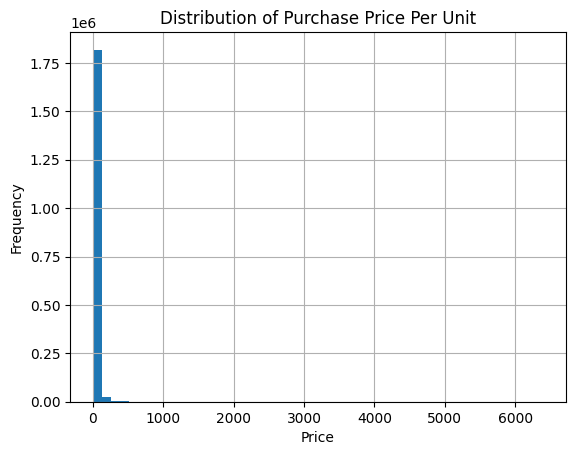

In [103]:
import matplotlib.pyplot as plt

plt.figure()
amazon_purchases_data["Purchase Price Per Unit"].hist(bins=50)
plt.title("Distribution of Purchase Price Per Unit")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

There is a huge spike arounf the 0-50 range then there is almost nothing there this tells us that most products are low priced here lets zoom in on that part

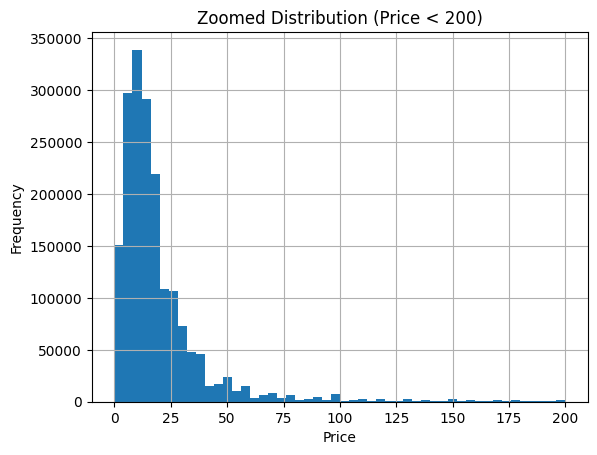

In [109]:
plt.figure()
amazon_purchases_data[
    amazon_purchases_data["Purchase Price Per Unit"] < 200
]["Purchase Price Per Unit"].hist(bins=50)

plt.title("Zoomed Distribution (Price < 200)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Most of the things are prices between 0-60 prices as we can see and very few are more than that. We can see long tail phenomenon here as people buy more things that are cheap than the expensive ones

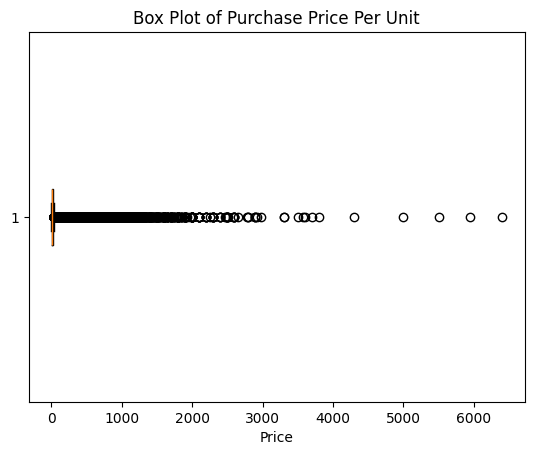

In [105]:
plt.figure()
plt.boxplot(amazon_purchases_data["Purchase Price Per Unit"], vert=False)
plt.title("Box Plot of Purchase Price Per Unit")
plt.xlabel("Price")
plt.show()

We cannot see anything here either lets zoom in a little

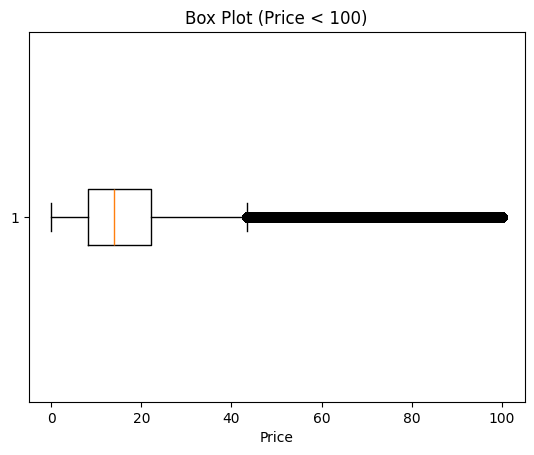

In [110]:
plt.figure()
plt.boxplot(
    amazon_purchases_data[
        amazon_purchases_data["Purchase Price Per Unit"] < 100
    ]["Purchase Price Per Unit"],
    vert=False
)

plt.title("Box Plot (Price < 100)")
plt.xlabel("Price")
plt.show()

Most purchases are low-priced (around 10–20), with typical values extending up to 40 and a long tail of higher-priced outliers

The central 50% of purchase prices lies between 8 and 23, with a median around 14, while higher-priced purchases above 40 are less frequent but still present

##### Lets find outliers

In [112]:
col = amazon_purchases_data["Purchase Price Per Unit"]

Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper bound (outlier threshold):", upper_bound)
print("Lower bound:", lower_bound)

Q1: 8.47
Q3: 23.75
IQR: 15.28
Upper bound (outlier threshold): 46.67
Lower bound: -14.449999999999998


In [113]:
outliers = col[col > upper_bound]

print("Number of outliers:", len(outliers))
print("Percentage of data:", len(outliers) / len(col) * 100)

Number of outliers: 143210
Percentage of data: 7.738082051442766


Ok 7.7% is a lot of outliers it is more than there should be maybe we should find soem other way to find the outliers 

Lets use Percentile method for this which is basically
- 95th percentile → high-value purchases
- 99th percentile → extreme purchases

We use it because Percentile method defines outliers based on how rare values are, not how far they are from the average

In [117]:
# Compute percentiles
col = amazon_purchases_data["Purchase Price Per Unit"]

p95 = col.quantile(0.95)
p99 = col.quantile(0.99)

print("95th percentile:", p95)
print("99th percentile:", p99)

95th percentile: 59.99
99th percentile: 174.99


In [118]:
high_value = col[col > p95]
extreme = col[col > p99]

print("High-value (top 5%) count:", len(high_value))
print("Extreme (top 1%) count:", len(extreme))

print("High-value %:", len(high_value) / len(col) * 100)
print("Extreme %:", len(extreme) / len(col) * 100)

High-value (top 5%) count: 89435
Extreme (top 1%) count: 18465
High-value %: 4.83245142288097
Extreme %: 0.9977214236428368


In [119]:
extreme.sort_values(ascending=False).head(10)

1201636    6398.95
190207     5949.00
1366289    5499.99
1154310    4999.00
185191     4299.00
1201623    3798.95
43141      3704.11
390097     3599.99
1366228    3579.00
1800657    3499.99
Name: Purchase Price Per Unit, dtype: float64

Looking at this behaviour we might need to break the users into segments and make the recommendation system depending on that

Now lets analyse the quantity feature

#### Quantity

In [127]:
# Summary Stats
amazon_purchases_data["Quantity"].describe()



count    1.850717e+06
mean     1.088636e+00
std      7.795341e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.390000e+02
Name: Quantity, dtype: float64

Even 75 percentile is 1 it is definately extreme long tail lets confirm that

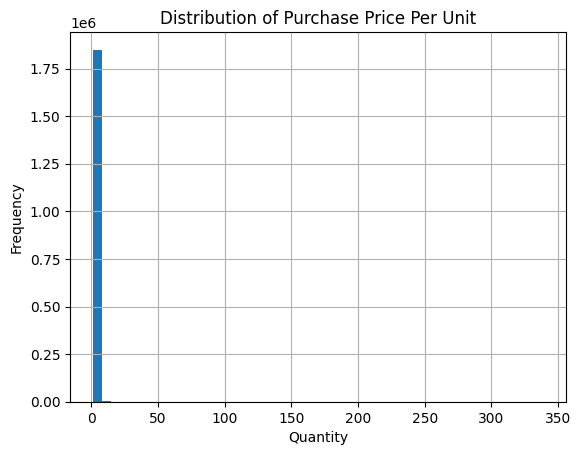

In [125]:

plt.figure()
amazon_purchases_data["Quantity"].hist(bins=50)
plt.title("Distribution of Purchase Price Per Unit")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

Same thing here we can see it is long tailed and I believe even this is extreme long tailed here too

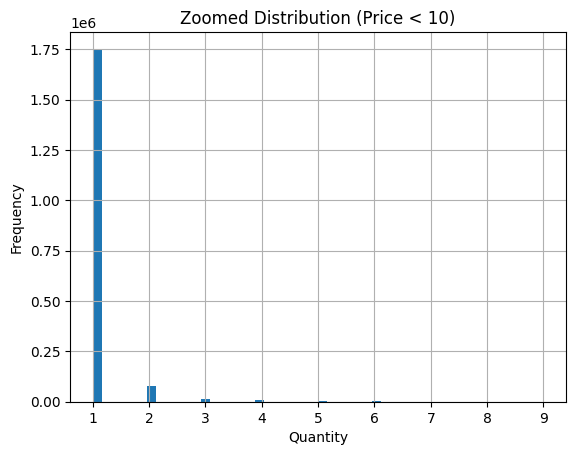

In [123]:
plt.figure()
amazon_purchases_data[
    amazon_purchases_data["Quantity"] < 10
]["Quantity"].hist(bins=50)

plt.title("Zoomed Distribution (Price < 10)")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

As we can see almost all people are buying 1 quantity and very few 2-3 and barely anyone more than that. This replicates real behaviour

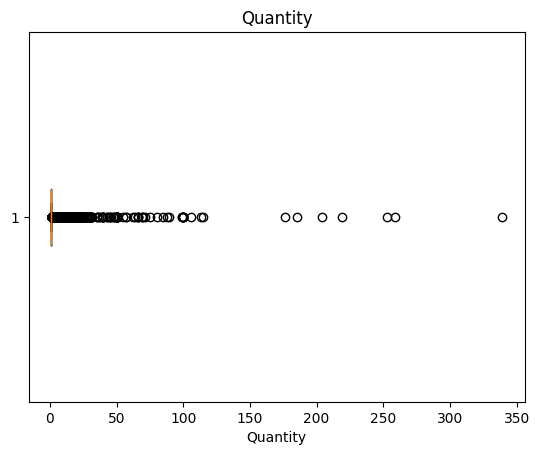

In [128]:
plt.figure()
plt.boxplot(amazon_purchases_data["Quantity"], vert=False)
plt.title("Quantity")
plt.xlabel("Quantity")
plt.show()

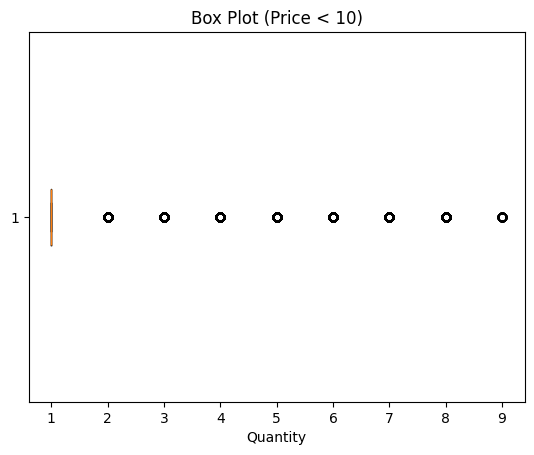

In [130]:
plt.figure()
plt.boxplot(
    amazon_purchases_data[
        amazon_purchases_data["Quantity"] < 10
    ]["Quantity"],
    vert=False
)

plt.title("Box Plot (Price < 10)")
plt.xlabel("Quantity")
plt.show()

the box plot is so small that it is in 1 itself I dont thinkwe can use normal approach here for finding outliers either but lets just confirm that

In [140]:
col = amazon_purchases_data["Quantity"]

Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper bound (outlier threshold):", upper_bound)
print("Lower bound:", lower_bound)

Q1: 1.0
Q3: 1.0
IQR: 0.0
Upper bound (outlier threshold): 1.0
Lower bound: 1.0


yeap definitely not going to work 

In [132]:
# Compute percentiles
col = amazon_purchases_data["Quantity"]

p95 = col.quantile(0.95)
p99 = col.quantile(0.99)

print("95th percentile:", p95)
print("99th percentile:", p99)

95th percentile: 2.0
99th percentile: 3.0


In [133]:
high_value = col[col > p95]
extreme = col[col > p99]

print("High-value (top 5%) count:", len(high_value))
print("Extreme (top 1%) count:", len(extreme))

print("High-value %:", len(high_value) / len(col) * 100)
print("Extreme %:", len(extreme) / len(col) * 100)

High-value (top 5%) count: 26232
Extreme (top 1%) count: 12279
High-value %: 1.4173966089899213
Extreme %: 0.6634725892721577


I am a little skeptical about this too but ig we cant really say much when almost everyone just buys one copy of whatever they are buying. So yes the data is not broken but we can say that this might be a problem while building a recommendation system


Now Lets move to next order date

#### Order Date

In [146]:
# Range of Data
min= amazon_purchases_data["Order Date"].min()
max= amazon_purchases_data["Order Date"].max()
print(f"Max: {max}\nMin: {min}")

Max: 2024-08-15 00:00:00
Min: 2018-01-01 00:00:00


In [137]:
amazon_purchases_data["Order Date"] = pd.to_datetime(
    amazon_purchases_data["Order Date"]
)

In [141]:
# Extract useful time features
amazon_purchases_data["year"] = amazon_purchases_data["Order Date"].dt.year
amazon_purchases_data["month"] = amazon_purchases_data["Order Date"].dt.month
amazon_purchases_data["day_of_week"] = amazon_purchases_data["Order Date"].dt.day_name()

In [142]:
# Count activity over time
# Purchases per year
amazon_purchases_data["year"].value_counts().sort_index()

year
2018    225465
2019    266016
2020    409212
2021    467870
2022    442230
2023     39923
2024         1
Name: count, dtype: int64

I notice that the year 2023 and 2024 have very little value. Lets see from when does the value decrease because from that point the servey was closed and the responses are from people who just had the link and filled way later

In [143]:
# Purchases per month
amazon_purchases_data["month"].value_counts().sort_index()

month
1     155897
2     138529
3     150775
4     140956
5     145319
6     149036
7     156094
8     153686
9     141292
10    152842
11    174146
12    192145
Name: count, dtype: int64

Monthwise everything seems correct to me only the last two months have purchases more than 160k everything else is around 150k. And the last two months might be holiday spikes that is black friday and Christmas 

In [144]:
# Purchases per day of week
amazon_purchases_data["day_of_week"].value_counts()

day_of_week
Monday       282591
Tuesday      274361
Wednesday    267604
Sunday       265252
Friday       257979
Thursday     255983
Saturday     246947
Name: count, dtype: int64

Purchases are almost same every day of the week nothing there

<Axes: xlabel='Order Date'>

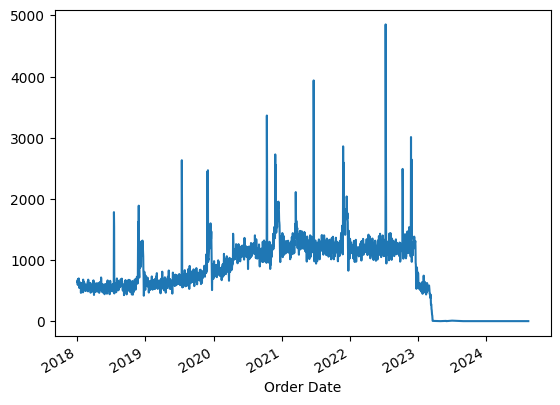

In [145]:
amazon_purchases_data.groupby("Order Date").size().plot()

There are random spikes to these I wonder what those can be. But we can see the 2023-2024 to be receeding and its too extreme

The data from 2023-24 would be removed from the training data mostly because it is incomplete and can do more harm than good if we will use date time as metric

Alright now Time to look at the datasets with null values in it. Lets start with address

Lets start with category

#### Product Category

In [148]:
category_data = amazon_purchases_data[
    amazon_purchases_data["Category"].notna()
]

In [149]:
category_data.describe()

,Order Date,Purchase Price Per Unit,Quantity,sales,year,month
count,1764851,1.764851e+06,1.764851e+06,1.764851e+06,1.764851e+06,1.764851e+06
mean,2020-12-18 23:24:48.969436672,2.254130e+01,1.089911e+00,2.369234e+01,2.020450e+03,6.719587e+00
min,2018-01-01 00:00:00,1.000000e-02,1.000000e+00,1.000000e-02,2.018000e+03,1.000000e+00
25%,2019-12-21 00:00:00,8.280000e+00,1.000000e+00,8.860000e+00,2.019000e+03,4.000000e+00
50%,2021-02-10 00:00:00,1.399000e+01,1.000000e+00,1.449000e+01,2.021000e+03,7.000000e+00
75%,2022-02-01 00:00:00,2.340000e+01,1.000000e+00,2.485000e+01,2.022000e+03,1.000000e+01
max,2024-08-15 00:00:00,6.398950e+03,3.390000e+02,6.398950e+03,2.024000e+03,1.200000e+01
std,NaN,4.547133e+01,7.886950e-01,4.877093e+01,1.358552e+00,3.525607e+00


In [150]:
# unique values
print("Unique categories:", category_data["Category"].nunique())

Unique categories: 1871


In [153]:
# Top categories
top_categories = category_data["Category"].value_counts()

print(top_categories.head(10))

Category
ABIS_BOOK                 87668
PET_FOOD                  38537
GIFT_CARD                 27735
SHIRT                     27272
NUTRITIONAL_SUPPLEMENT    27096
ELECTRONIC_CABLE          18277
HEALTH_PERSONAL_CARE      16693
MEDICATION                16400
PANTS                     15952
CELLULAR_PHONE_CASE       15378
Name: count, dtype: int64


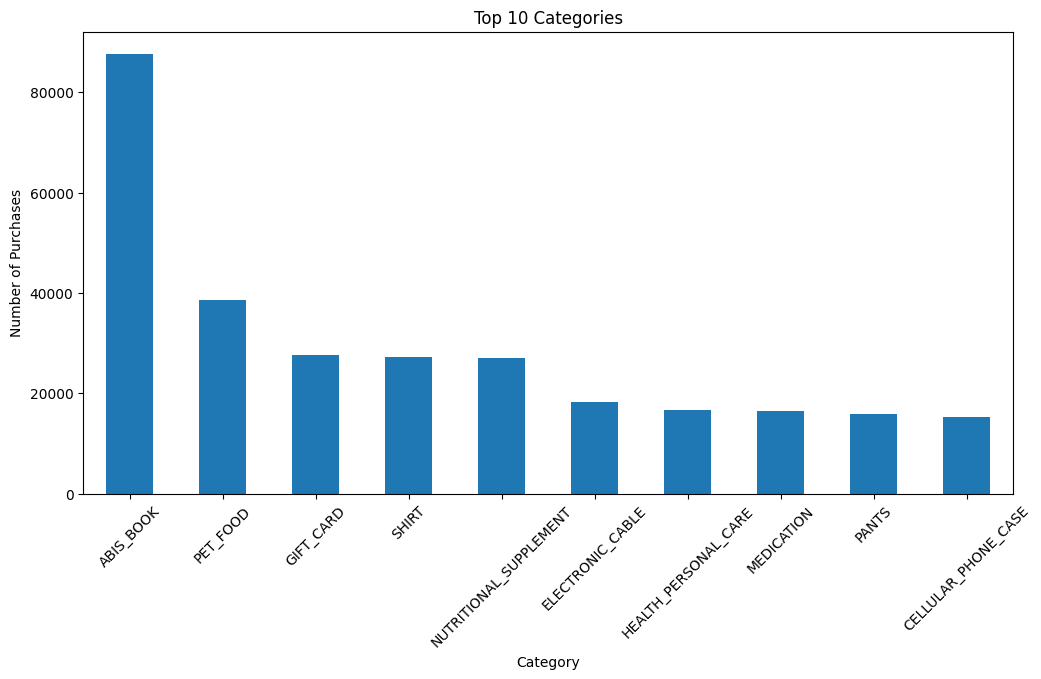

In [169]:
# Bar chart
plt.figure(figsize=(12, 6))

top_categories.head(10).plot(kind="bar")

plt.title("Top 10 Categories")
plt.xlabel("Category")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=45)

plt.show()

In [170]:
# Percentage contribution of top 10 categories
top_10_percent = (
    top_categories.head(10).sum()
    / len(category_data)
) * 100

print("Top 10 categories contribute:",
      top_10_percent,
      "% of all purchases")

Top 10 categories contribute: 16.489097379892126 % of all purchases


The top categories dominates this purchase chart relative to others but still the top 10 items just cover 16.5% of purchases which means that probably the buying rate of other categories is similar 

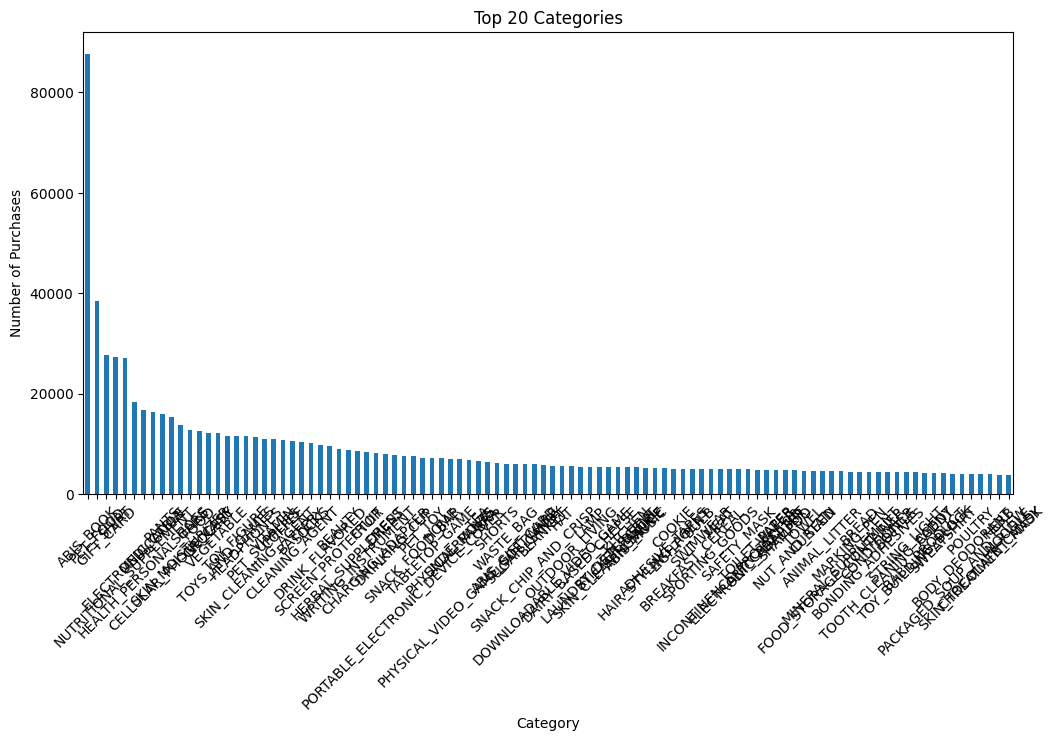

In [167]:
# Bar chart
plt.figure(figsize=(12, 6))

top_categories.head(100).plot(kind="bar")

plt.title("Top 20 Categories")
plt.xlabel("Category")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=45)

plt.show()

In [172]:
# Percentage contribution of top 10 categories
top_100_percent = (
    top_categories.head(100).sum()
    / len(category_data)
) * 100

print("Top 100 categories contribute:",
      top_100_percent,
      "% of all purchases")

Top 100 categories contribute: 50.14519639334992 % of all purchases


In [156]:
# Rare categories
rare_categories = (top_categories == 1).sum()

print("Categories appearing only once:",
      rare_categories)

Categories appearing only once: 70


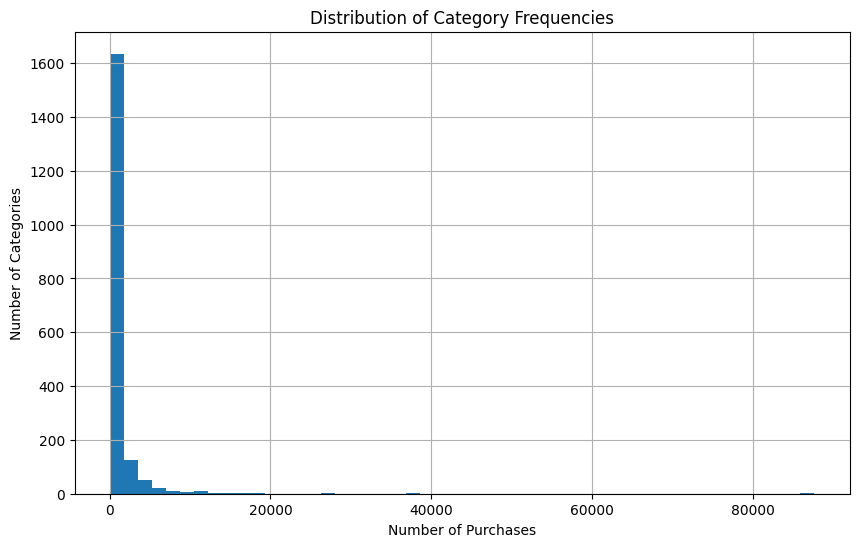

In [157]:
# Distribution of category frequencies
plt.figure(figsize=(10, 6))

top_categories.hist(bins=50)

plt.title("Distribution of Category Frequencies")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Categories")

plt.show()

In [158]:
top_categories.describe()

count     1871.000000
mean       943.266168
std       3016.363490
min          1.000000
25%         54.500000
50%        219.000000
75%        751.500000
max      87668.000000
Name: count, dtype: float64

Lets go with address next

#### Address

In [175]:
Shipping_Address_data = amazon_purchases_data[
    amazon_purchases_data["Shipping Address State"].notna()
]

In [176]:
Shipping_Address_data.describe()

,Order Date,Purchase Price Per Unit,Quantity,sales,year,month
count,1826535,1.826535e+06,1.826535e+06,1.826535e+06,1.826535e+06,1.826535e+06
mean,2020-12-03 01:39:44.971544320,2.266333e+01,1.087999e+00,2.380123e+01,2.020408e+03,6.707790e+00
min,2018-01-01 00:00:00,1.000000e-02,1.000000e+00,1.000000e-02,2.018000e+03,1.000000e+00
25%,2019-12-06 00:00:00,8.490000e+00,1.000000e+00,8.950000e+00,2.019000e+03,4.000000e+00
50%,2021-01-20 00:00:00,1.399000e+01,1.000000e+00,1.479000e+01,2.021000e+03,7.000000e+00
75%,2022-01-17 00:00:00,2.376000e+01,1.000000e+00,2.495000e+01,2.022000e+03,1.000000e+01
max,2023-09-01 00:00:00,6.398950e+03,3.390000e+02,6.398950e+03,2.023000e+03,1.200000e+01
std,NaN,4.585429e+01,7.597138e-01,4.905218e+01,1.366767e+00,3.526500e+00


In [190]:
# unique values
print("Unique categories:", Shipping_Address_data["Shipping Address State"].nunique())

Unique categories: 52


In [191]:
# Top categories
top_states = Shipping_Address_data["Shipping Address State"].value_counts()

print(top_states)

Shipping Address State
CA    187070
TX    141172
FL    114387
NY    107664
PA    100521
OH     88409
IL     74433
NC     73923
MI     62417
GA     55079
WA     54972
VA     52160
NJ     47350
MA     46509
IN     45908
WI     38513
OR     37239
TN     36077
MD     35298
AZ     34007
CO     30305
MN     30069
KY     28340
NV     22040
LA     20945
SC     20062
MO     19472
AL     18711
OK     18299
CT     17831
KS     15657
AR     14852
UT     14118
NE     12769
NH     12381
MS     11917
IA     11479
WV     11251
NM      9022
DC      8716
DE      7918
ID      6696
ME      6649
RI      5605
HI      5233
VT      3903
MT      2821
SD      2548
AK      1862
ND      1042
WY       877
PR        37
Name: count, dtype: int64


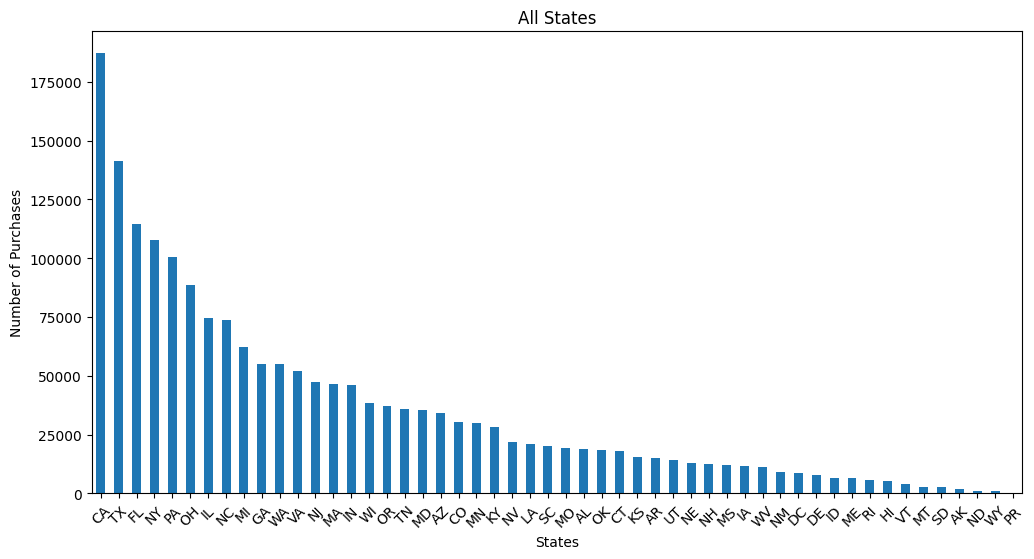

In [192]:
plt.figure(figsize=(12, 6))

top_states.plot(kind="bar")

plt.title("All States")
plt.xlabel("States")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=45)

plt.show()

In [193]:
# Percentage contribution of top 10 categories
top_10_percent_states = (
    top_states.head(10).sum()
    / len(Shipping_Address_data)
) * 100

print("Top 10 staes contribute:",
      top_10_percent_states,
      "% of all purchases")

Top 10 staes contribute: 55.026320327833844 % of all purchases


Not all orders are equally divided either top 10 categories contribute more than 50 percent

In [194]:
top_states.describe()

count        52.000000
mean      35125.673077
std       38918.217407
min          37.000000
25%        8945.500000
50%       19767.000000
75%       46719.250000
max      187070.000000
Name: count, dtype: float64

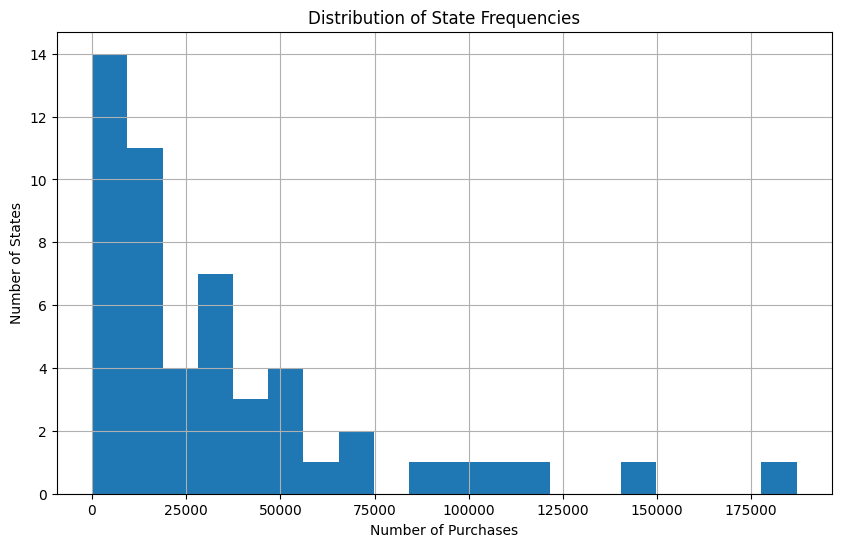

In [195]:
plt.figure(figsize=(10, 6))

top_states.hist(bins=20)

plt.title("Distribution of State Frequencies")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of States")

plt.show()

Lets now go to title


#### Title

In [196]:
Product_Title_data = amazon_purchases_data[
    amazon_purchases_data["Title"].notna()
]

In [197]:
Product_Title_data.describe()

,Order Date,Purchase Price Per Unit,Quantity,sales,year,month
count,1764606,1.764606e+06,1.764606e+06,1.764606e+06,1.764606e+06,1.764606e+06
mean,2020-12-19 00:41:13.452317184,2.254244e+01,1.089928e+00,2.369367e+01,2.020451e+03,6.719367e+00
min,2018-01-01 00:00:00,1.000000e-02,1.000000e+00,1.000000e-02,2.018000e+03,1.000000e+00
25%,2019-12-21 00:00:00,8.280000e+00,1.000000e+00,8.860000e+00,2.019000e+03,4.000000e+00
50%,2021-02-10 00:00:00,1.399000e+01,1.000000e+00,1.449000e+01,2.021000e+03,7.000000e+00
75%,2022-02-01 00:00:00,2.340000e+01,1.000000e+00,2.485000e+01,2.022000e+03,1.000000e+01
max,2024-08-15 00:00:00,6.398950e+03,3.390000e+02,6.398950e+03,2.024000e+03,1.200000e+01
std,NaN,4.547048e+01,7.887542e-01,4.877054e+01,1.358494e+00,3.525591e+00


In [199]:
# unique values
print("Unique categories:", Product_Title_data["Title"].nunique())

Unique categories: 824722


In [200]:
# Top categories
top_products = Product_Title_data["Title"].value_counts()

print(top_products.head(10))

Title
Amazon.com Gift Card Balance Reload                                                                           11373
Amazon Reload                                                                                                  6305
Amazon.com eGift Card                                                                                          5587
Google Play gift code - give the gift of games, apps and more (Email Delivery - US Only)                        878
1                                                                                                               792
Group Gift Wedding Contribution                                                                                 734
$10 -PlayStation Store Gift Card [Digital Code]                                                                 634
Amazon Basics 48 Pack AA High-Performance Alkaline Batteries, 10-Year Shelf Life, Easy to Open Value Pack       573
Amazon Basics 36 Pack AAA High-Performance Alkaline Batteries, 10-

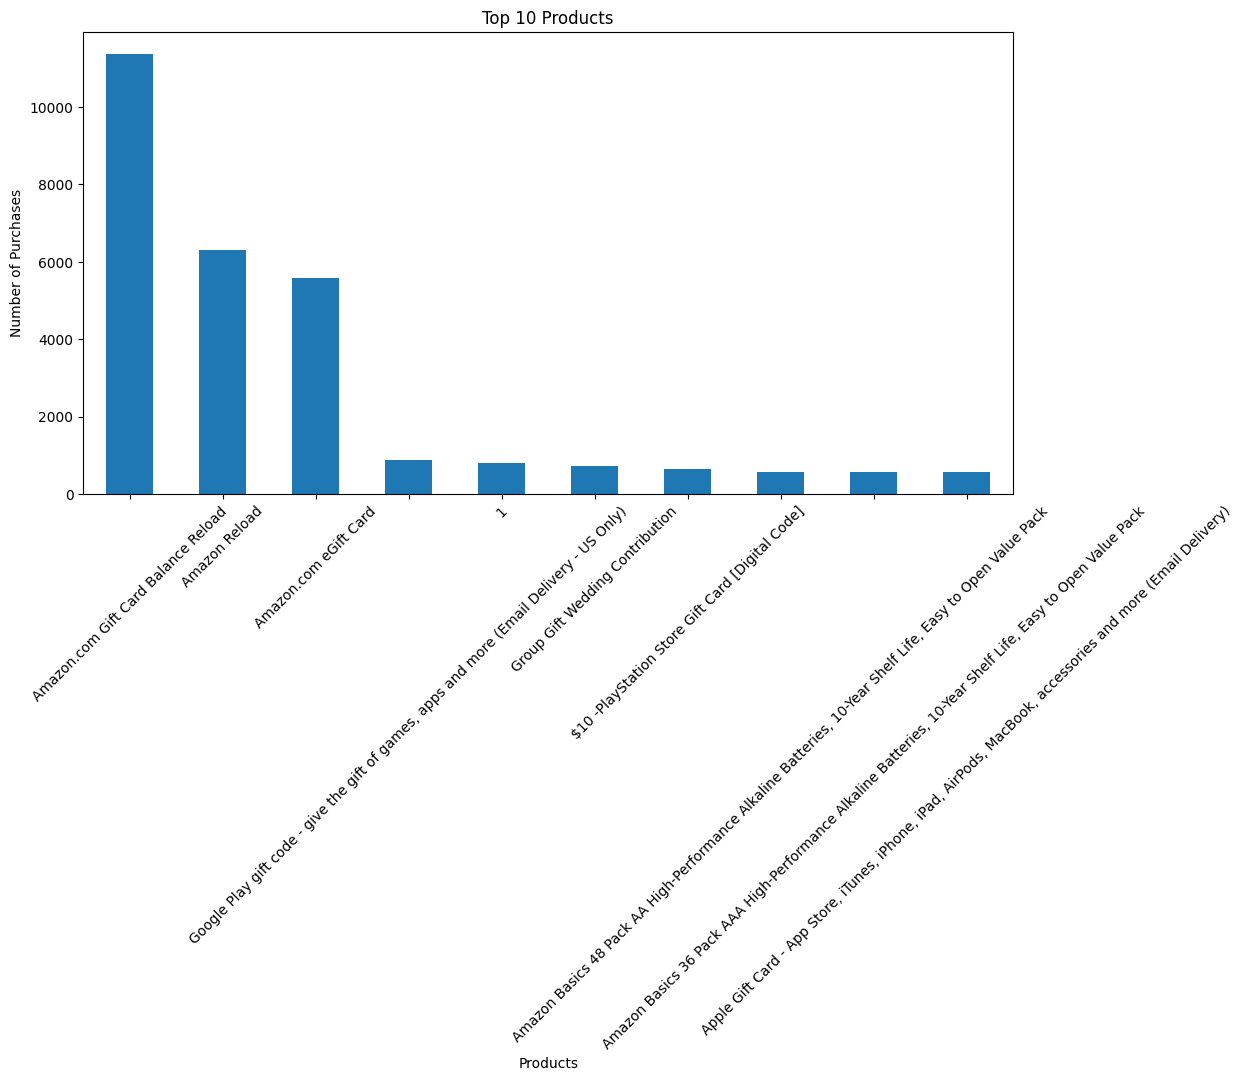

In [201]:
# Bar chart
plt.figure(figsize=(12, 6))

top_products.head(10).plot(kind="bar")

plt.title("Top 10 Products")
plt.xlabel("Products")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=45)

plt.show()

In [202]:
# Percentage contribution of top 10 categories
top_10_percent_products = (
    top_products.head(10).sum()
    / len(Product_Title_data)
) * 100

print("Top 10 products contribute:",
      top_10_percent_products,
      "% of all purchases")

Top 10 products contribute: 1.587323175825085 % of all purchases


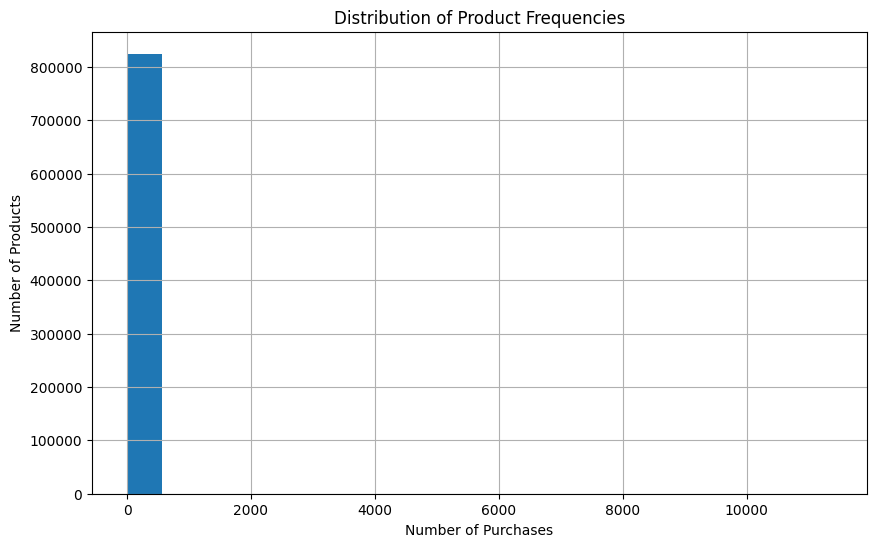

In [203]:
plt.figure(figsize=(10, 6))

top_products.hist(bins=20)

plt.title("Distribution of Product Frequencies")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Products")

plt.show()

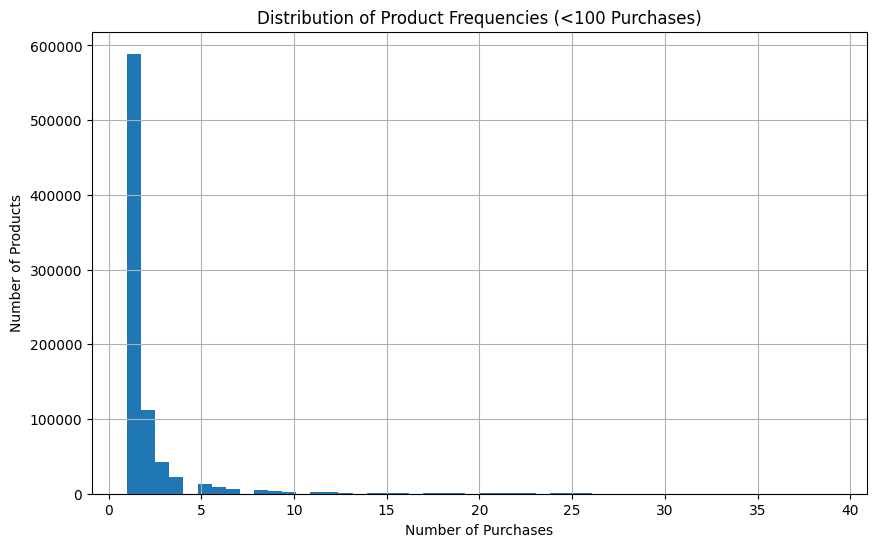

In [205]:
plt.figure(figsize=(10, 6))

top_products[
    top_products < 40
].hist(bins=50)

plt.title("Distribution of Product Frequencies (<100 Purchases)")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Products")

plt.show()

In [206]:
top_products.describe()

count    824722.000000
mean          2.139637
std          16.507667
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max       11373.000000
Name: count, dtype: float64

Almost same case as the quantity part. Most people buy just ne product at a time

ALright lets move on to the servey and plot that to see what is that data telling us

### Univariate Analysis(Servey Data)

In [207]:
servey_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5027 entries, 0 to 5026
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Survey ResponseID           5027 non-null   object
 1   Q-demos-age                 5027 non-null   object
 2   Q-demos-hispanic            5027 non-null   object
 3   Q-demos-race                5027 non-null   object
 4   Q-demos-education           5027 non-null   object
 5   Q-demos-income              5027 non-null   object
 6   Q-demos-gender              5027 non-null   object
 7   Q-sexual-orientation        5027 non-null   object
 8   Q-demos-state               5027 non-null   object
 9   Q-amazon-use-howmany        5027 non-null   object
 10  Q-amazon-use-hh-size        5027 non-null   object
 11  Q-amazon-use-how-oft        5027 non-null   object
 12  Q-substance-use-cigarettes  5027 non-null   object
 13  Q-substance-use-marijuana   5027 non-null   obje

#### Age

In [225]:
servey_data["Q-demos-age"].value_counts()

Q-demos-age
25 - 34 years    1813
35 - 44 years    1240
18 - 24 years     768
45 - 54 years     677
55 - 64 years     374
65 and older      155
Name: count, dtype: int64

<Axes: xlabel='Q-demos-age'>

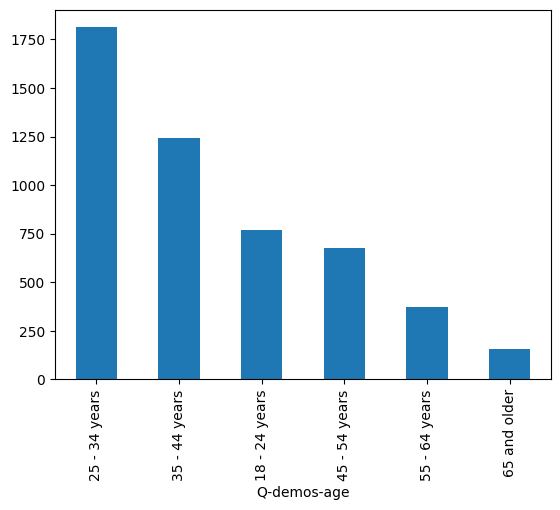

In [226]:
servey_data["Q-demos-age"].value_counts().plot(kind="bar")

#### Hispanic Origin

In [212]:
servey_data["Q-demos-hispanic"].value_counts()

Q-demos-hispanic
No     4478
Yes     549
Name: count, dtype: int64

<Axes: xlabel='Q-demos-hispanic'>

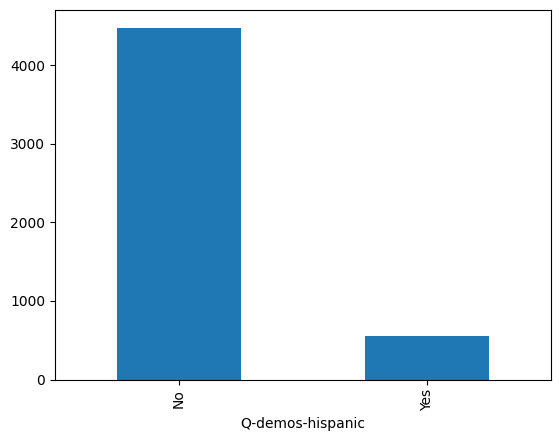

In [213]:
servey_data["Q-demos-hispanic"].value_counts().plot(kind="bar")

#### Race

In [218]:
Unique_servey_data_Race= servey_data["Q-demos-race"].str.split(",").explode()
Unique_servey_data_Race

0       Black or African American
1              White or Caucasian
2              White or Caucasian
3              White or Caucasian
4              White or Caucasian
                  ...            
5022           White or Caucasian
5023           White or Caucasian
5024    Black or African American
5025           White or Caucasian
5026           White or Caucasian
Name: Q-demos-race, Length: 5329, dtype: object

In [215]:
servey_data["Q-demos-race"].value_counts()


Q-demos-race
White or Caucasian                                                                               3886
Asian                                                                                             377
Black or African American                                                                         351
Other                                                                                             105
White or Caucasian,Asian                                                                           76
White or Caucasian,Black or African American                                                       60
White or Caucasian,American Indian/Native American or Alaska Native                                56
American Indian/Native American or Alaska Native                                                   32
White or Caucasian,Other                                                                           23
White or Caucasian,Black or African American,American Indian/Native A

In [219]:
Unique_servey_data_Race.value_counts()

Q-demos-race
White or Caucasian                                  4133
Asian                                                483
Black or African American                            448
Other                                                135
American Indian/Native American or Alaska Native     111
Native Hawaiian or Other Pacific Islander             19
Name: count, dtype: int64

<Axes: xlabel='Q-demos-race'>

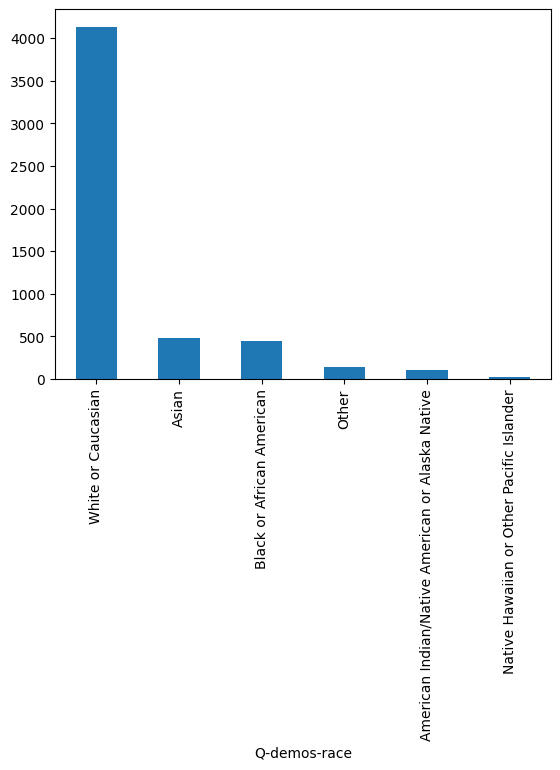

In [220]:
Unique_servey_data_Race.value_counts().plot(kind="bar")

#### Education

In [221]:
servey_data["Q-demos-education"].value_counts()

Q-demos-education
Bachelor's degree                                                       2219
High school diploma or GED                                              1860
Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS, etc)     870
Some high school or less                                                  46
Prefer not to say                                                         32
Name: count, dtype: int64

<Axes: xlabel='Q-demos-education'>

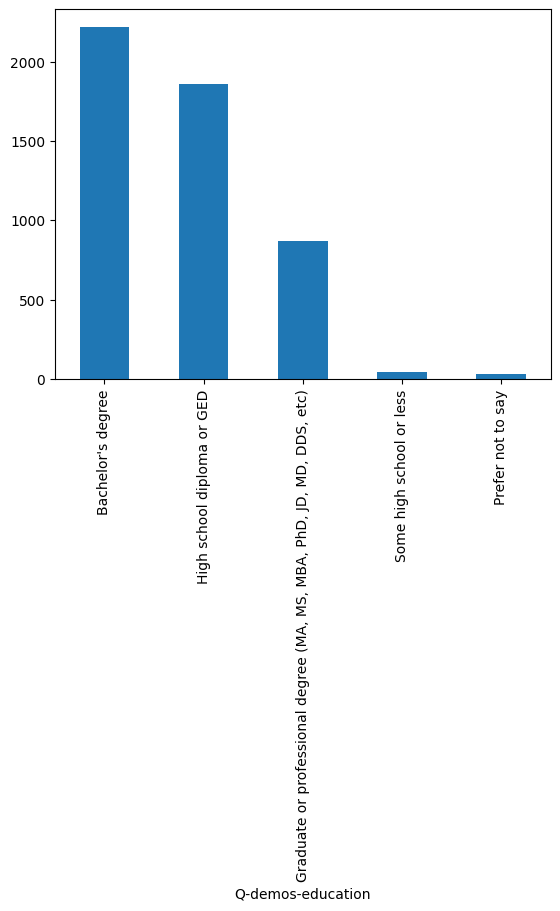

In [222]:
servey_data["Q-demos-education"].value_counts().plot(kind="bar")

#### Income

In [223]:
servey_data["Q-demos-income"].value_counts()

Q-demos-income
$25,000 - $49,999      1189
$50,000 - $74,999      1063
$100,000 - $149,999     790
$75,000 - $99,999       761
Less than $25,000       685
$150,000 or more        463
Prefer not to say        76
Name: count, dtype: int64

<Axes: xlabel='Q-demos-income'>

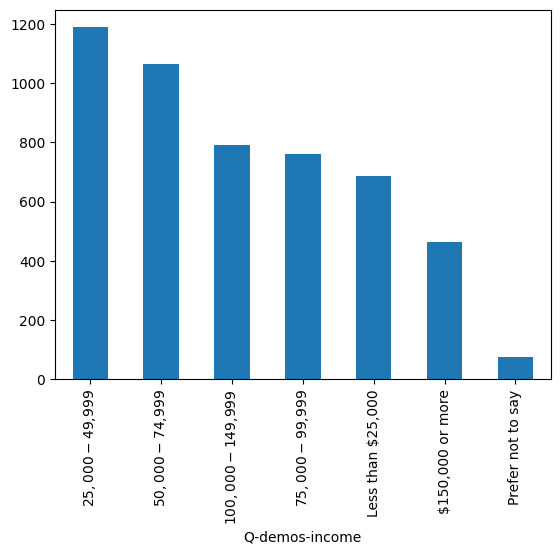

In [224]:
servey_data["Q-demos-income"].value_counts().plot(kind="bar")


#### Gender

In [227]:
servey_data["Q-demos-gender"].value_counts()

Q-demos-gender
Female               2589
Male                 2311
Other                 116
Prefer not to say      11
Name: count, dtype: int64

<Axes: xlabel='Q-demos-gender'>

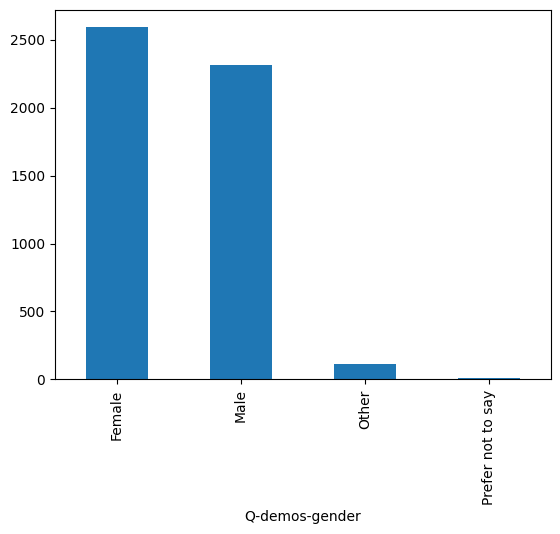

In [228]:
servey_data["Q-demos-gender"].value_counts().plot(kind="bar")

#### Sexual Orientation

In [229]:
servey_data["Q-sexual-orientation"].value_counts()


Q-sexual-orientation
heterosexual (straight)    3858
LGBTQ+                     1111
prefer not to say            58
Name: count, dtype: int64

<Axes: xlabel='Q-sexual-orientation'>

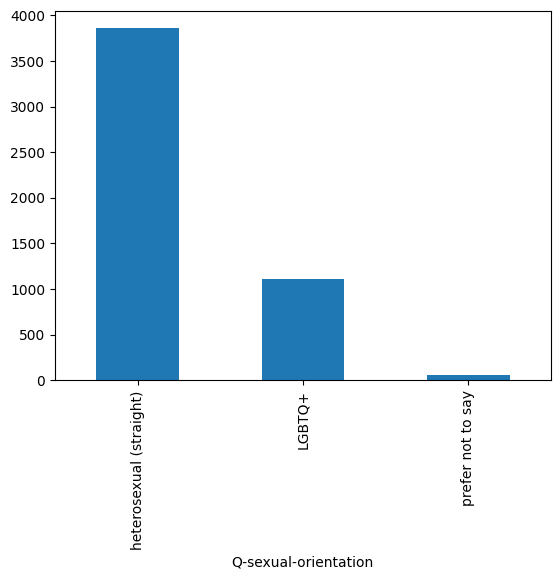

In [230]:
servey_data["Q-sexual-orientation"].value_counts().plot(kind="bar")

#### State

In [231]:
servey_data["Q-demos-state"].value_counts()

Q-demos-state
California                               505
Texas                                    384
Florida                                  327
New York                                 300
Pennsylvania                             275
Ohio                                     219
Illinois                                 216
North Carolina                           189
Michigan                                 164
Georgia                                  161
Virginia                                 148
Washington                               123
Indiana                                  121
Massachusetts                            117
New Jersey                               117
Tennessee                                105
Maryland                                 103
Oregon                                   103
Wisconsin                                100
Minnesota                                 97
Arizona                                   95
Kentucky                                 

<Axes: xlabel='Q-demos-state'>

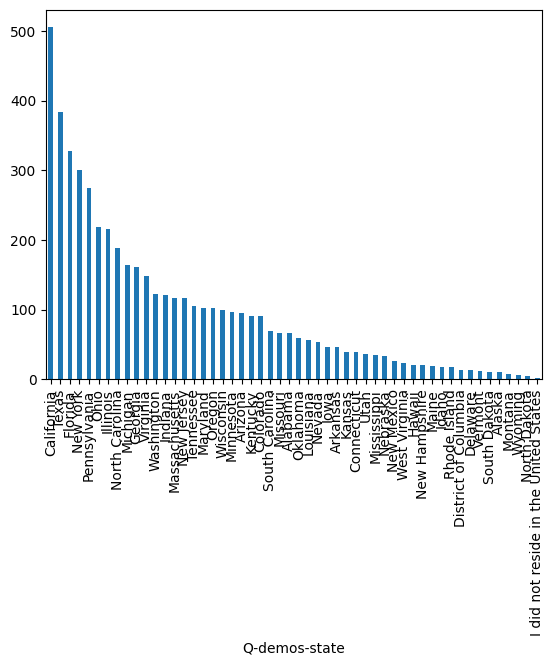

In [232]:
servey_data["Q-demos-state"].value_counts().plot(kind="bar")

#### How many People Share account

In [233]:
servey_data["Q-amazon-use-howmany"].value_counts()


Q-amazon-use-howmany
1 (just me!)    3546
2               1096
3                245
4+               140
Name: count, dtype: int64

<Axes: xlabel='Q-amazon-use-howmany'>

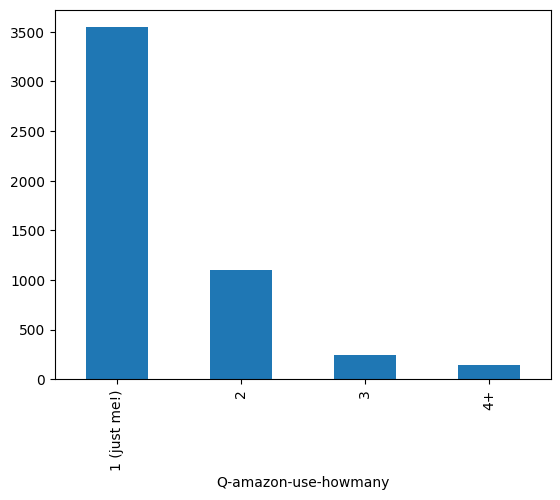

In [234]:
servey_data["Q-amazon-use-howmany"].value_counts().plot(kind="bar")

#### Household Size

In [235]:
servey_data["Q-amazon-use-hh-size"].value_counts()

Q-amazon-use-hh-size
2               1590
4+              1255
1 (just me!)    1199
3                983
Name: count, dtype: int64

<Axes: xlabel='Q-amazon-use-hh-size'>

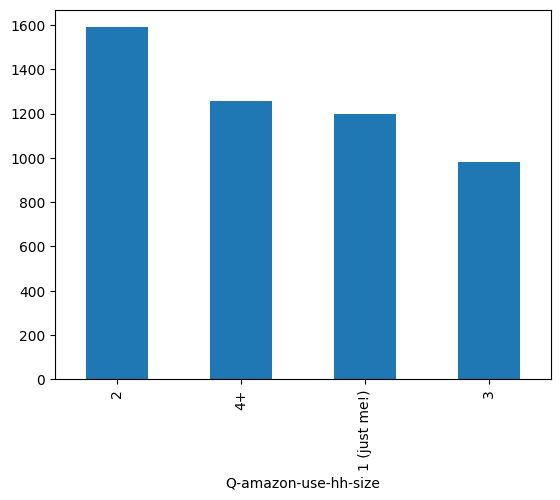

In [236]:
servey_data["Q-amazon-use-hh-size"].value_counts().plot(kind="bar")

#### Amazon Use frequency

In [237]:
servey_data["Q-amazon-use-how-oft"].value_counts()


Q-amazon-use-how-oft
Less than 5 times per month     3239
5 - 10 times per month          1407
More than 10 times per month     381
Name: count, dtype: int64

<Axes: xlabel='Q-amazon-use-how-oft'>

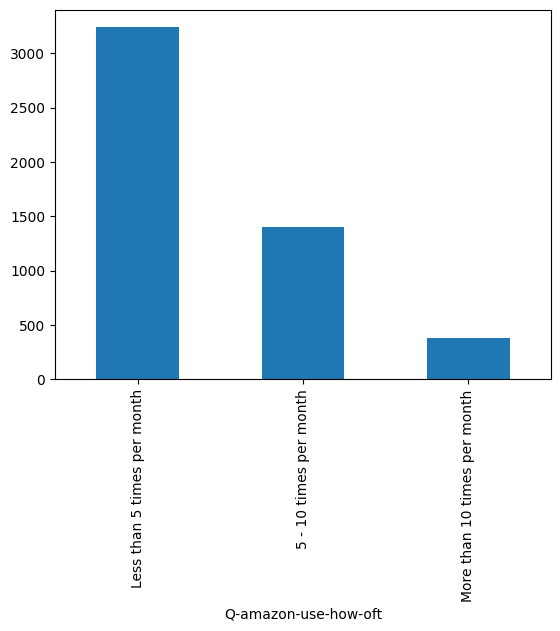

In [238]:
servey_data["Q-amazon-use-how-oft"].value_counts().plot(kind="bar")

#### Cigarette consumers

In [239]:
servey_data["Q-substance-use-cigarettes"].value_counts()

Q-substance-use-cigarettes
No                              4097
Yes                              755
I stopped in the recent past     163
Prefer not to say                 12
Name: count, dtype: int64

<Axes: xlabel='Q-substance-use-cigarettes'>

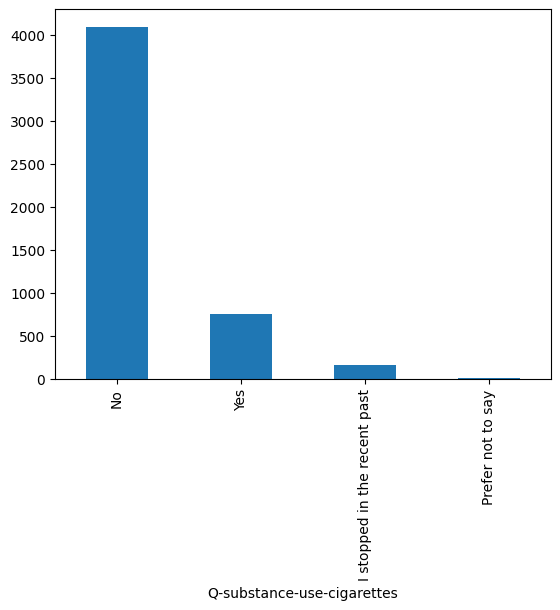

In [240]:
servey_data["Q-substance-use-cigarettes"].value_counts().plot(kind="bar")

#### Marijuana Consuemrs

In [241]:
servey_data["Q-substance-use-marijuana"].value_counts()

Q-substance-use-marijuana
No                              3781
Yes                             1061
I stopped in the recent past     138
Prefer not to say                 47
Name: count, dtype: int64

<Axes: xlabel='Q-substance-use-marijuana'>

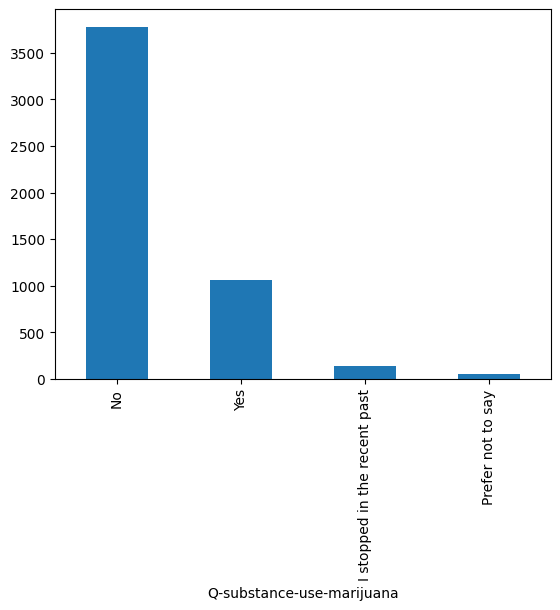

In [242]:
servey_data["Q-substance-use-marijuana"].value_counts().plot(kind="bar")

#### Alcohol Consumers

In [243]:
servey_data["Q-substance-use-alcohol"].value_counts()

Q-substance-use-alcohol
No                              2639
Yes                             2211
I stopped in the recent past     154
Prefer not to say                 23
Name: count, dtype: int64

<Axes: xlabel='Q-substance-use-alcohol'>

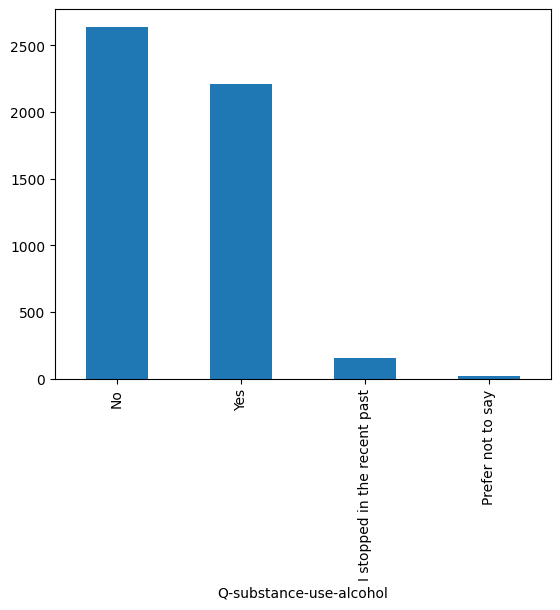

In [244]:
servey_data["Q-substance-use-alcohol"].value_counts().plot(kind="bar")

#### Users with Diabetes 

In [245]:
servey_data["Q-personal-diabetes"].value_counts()

Q-personal-diabetes
No                   4394
Yes                   617
Prefer not to say      16
Name: count, dtype: int64

<Axes: xlabel='Q-personal-diabetes'>

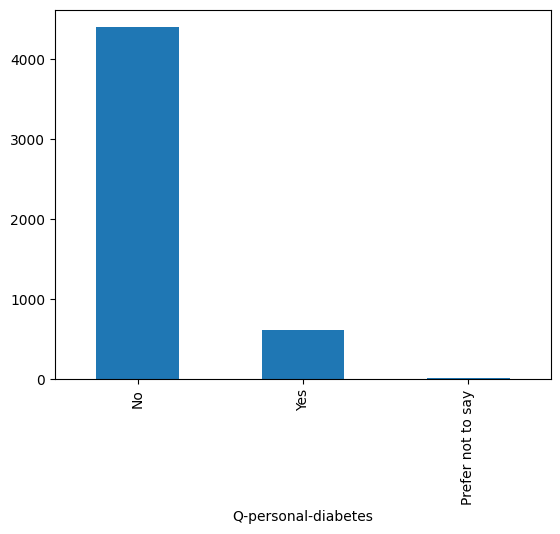

In [246]:
servey_data["Q-personal-diabetes"].value_counts().plot(kind="bar")

#### Users with Wheelchair

In [247]:
servey_data["Q-personal-wheelchair"].value_counts()

Q-personal-wheelchair
No                   4918
Yes                    98
Prefer not to say      11
Name: count, dtype: int64

<Axes: xlabel='Q-personal-wheelchair'>

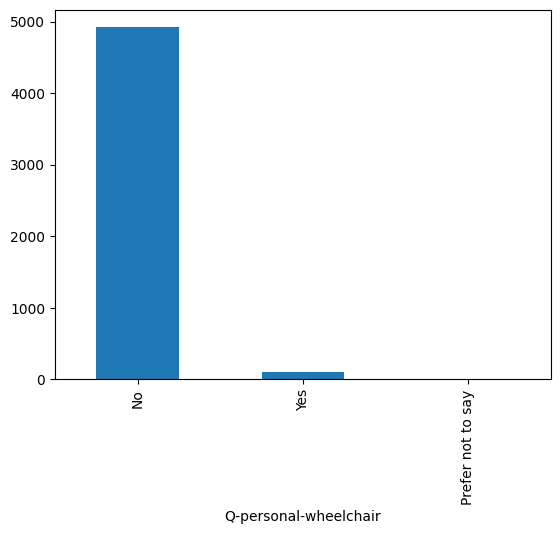

In [248]:
servey_data["Q-personal-wheelchair"].value_counts().plot(kind="bar")

#### Life Changes

In [249]:
servey_data["Q-life-changes"].value_counts()

Q-life-changes
No                                                                  3384
Moved place of residence                                             808
Lost a job                                                           347
Lost a job ,Moved place of residence                                 183
Had a child                                                           63
Became pregnant                                                       57
Became pregnant,Had a child                                           33
Divorce,Moved place of residence                                      22
Divorce                                                               18
Moved place of residence,Had a child                                  16
Moved place of residence,Became pregnant,Had a child                  15
Moved place of residence,Became pregnant                              13
Lost a job ,Had a child                                               12
Lost a job ,Divorce,Moved place of r

In [250]:
Unique_servey_data_life_changes= servey_data["Q-life-changes"].str.split(",").explode()
Unique_servey_data_life_changes

0       Lost a job 
1                No
2                No
3                No
4                No
           ...     
5022             No
5023             No
5024             No
5025             No
5026             No
Name: Q-life-changes, Length: 5439, dtype: object

In [252]:
Unique_servey_data_life_changes.value_counts()

Q-life-changes
No                          3384
Moved place of residence    1091
Lost a job                   596
Had a child                  159
Became pregnant              145
Divorce                       64
Name: count, dtype: int64

<Axes: xlabel='Q-life-changes'>

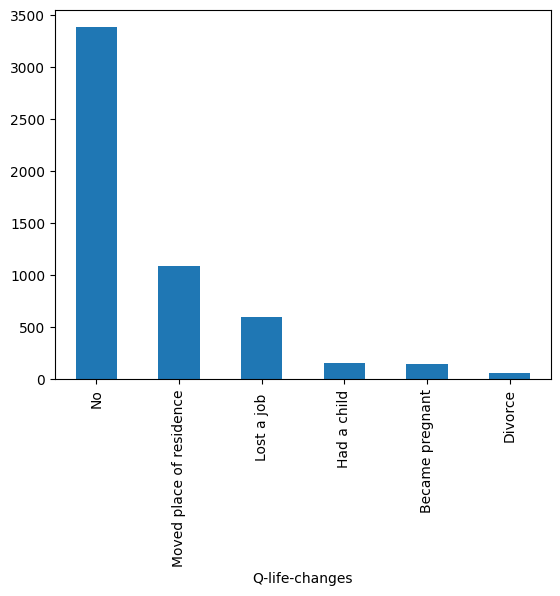

In [253]:
Unique_servey_data_life_changes.value_counts().plot(kind="bar")

#### Should Amazon Sell your data

In [254]:
servey_data["Q-sell-YOUR-data"].value_counts()

Q-sell-YOUR-data
Yes if I get part of the profit    2535
No                                 2142
Yes                                 194
I don't know                        156
Name: count, dtype: int64

<Axes: xlabel='Q-sell-YOUR-data'>

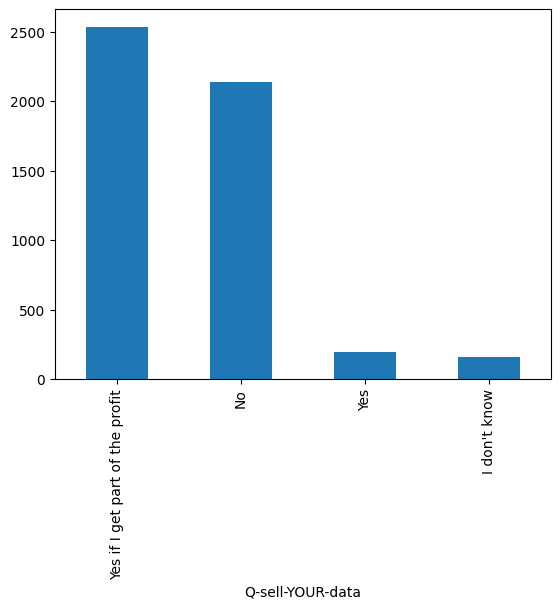

In [255]:
servey_data["Q-sell-YOUR-data"].value_counts().plot(kind="bar")

#### Should Small bussiness access this data fro free to help them compete with big companies

In [257]:
servey_data["Q-small-biz-use"].value_counts()

Q-small-biz-use
No              1923
Yes             1827
I don't know    1277
Name: count, dtype: int64

<Axes: xlabel='Q-small-biz-use'>

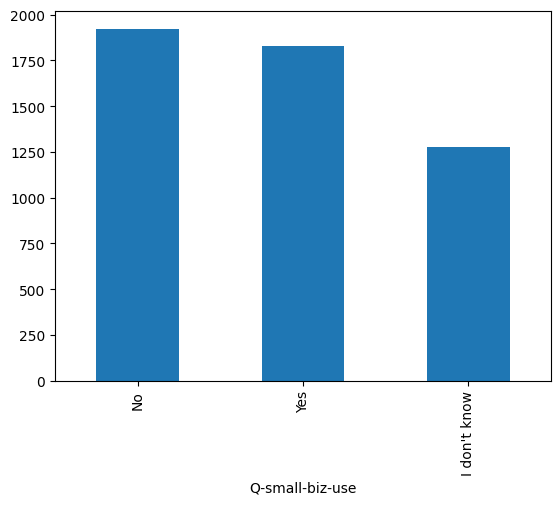

In [258]:
servey_data["Q-small-biz-use"].value_counts().plot(kind="bar")

#### Should the U.S. Census Bureau should use purchase data to supplement their existing surveys?


In [259]:
servey_data["Q-census-use"].value_counts()

Q-census-use
No              2332
I don't know    1413
Yes             1282
Name: count, dtype: int64

<Axes: xlabel='Q-census-use'>

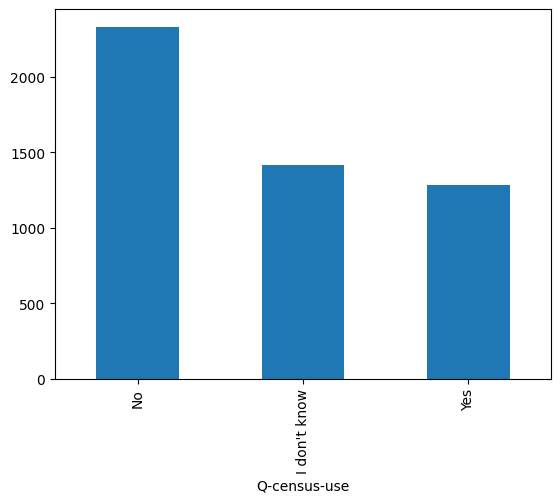

In [260]:
servey_data["Q-census-use"].value_counts().plot(kind="bar")

#### Do you think researchers should be able to use purchase data to understand societal changes (e.g. due to COVID-19)?

In [261]:
servey_data["Q-research-society"].value_counts()

Q-research-society
Yes             3223
No               940
I don't know     864
Name: count, dtype: int64

<Axes: xlabel='Q-research-society'>

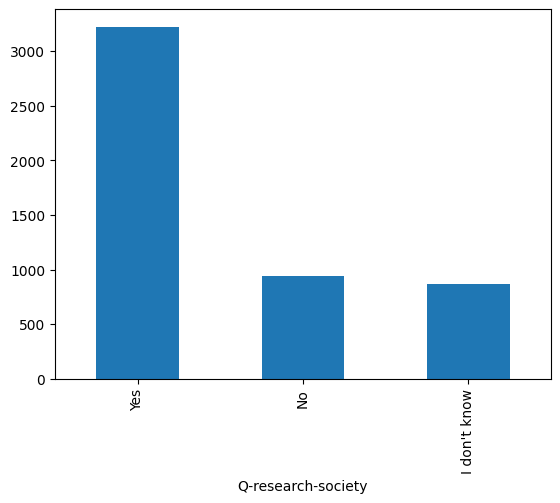

In [262]:
servey_data["Q-research-society"].value_counts().plot(kind="bar")

#### Should companies be able to sell consumer purchase data to other companies?

In [263]:
servey_data["Q-sell-consumer-data"].value_counts()

Q-sell-consumer-data
Yes if consumers get part of the profit    2451
No                                         2135
Yes                                         221
I don't know                                220
Name: count, dtype: int64

<Axes: xlabel='Q-sell-consumer-data'>

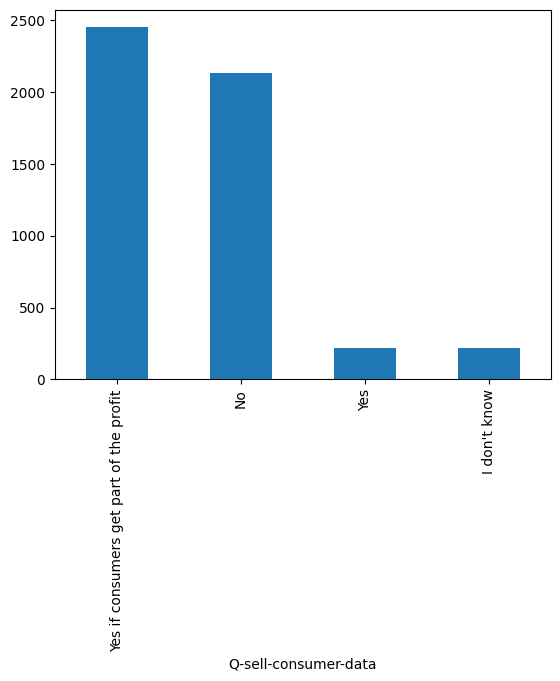

In [264]:
servey_data["Q-sell-consumer-data"].value_counts().plot(kind="bar")

### Relationships